This assignment focuses on Exploratory Data Analysis (EDA) as an important initial step in the CRISP-DM framework. EDA involves examining the structure of the dataset, identifying important variables, detecting unusual values, and exploring patterns or relationships. Before applying more complex models, EDA helps create a clearer picture of what the data looks like and what questions might be worth investigating further.

The PhiUSIIL Phishing URL Dataset includes URLs labeled as legitimate or phishing, along with various features related to their content and structure. Applying EDA to this dataset can show how phishing URLs differ from non-phishing ones, reveal the distribution of various characteristics, and uncover any interesting correlations. By gaining a better understanding of these elements, it becomes possible to guide future analysis and determine the most effective approaches to more advanced methods.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Import Dataset

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1vTx2WjTEGhj3etkO5JnXKr5PgJNkvlG1')
df.head()

,id,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,1,NaN,https://www.northcm.ac.th,24.0,www.northcm.ac.th,17.0,0.0,NaN,0.800000,NaN,...,0.0,0.0,1.0,NaN,3.0,NaN,69.0,NaN,NaN,1
1,4,8135291.txt,http://uqr.to/1il1z,NaN,NaN,NaN,NaN,to,1.000000,0.000896,...,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,1.0,0
2,5,586561.txt,https://www.woolworthsrewards.com.au,35.0,www.woolworthsrewards.com.au,28.0,0.0,au,0.857143,NaN,...,1.0,0.0,1.0,33.0,7.0,8.0,15.0,NaN,2.0,1
3,6,NaN,NaN,31.0,NaN,NaN,NaN,com,0.562500,0.522907,...,1.0,0.0,1.0,24.0,5.0,14.0,NaN,NaN,NaN,1
4,11,412632.txt,NaN,NaN,www.nyprowrestling.com,22.0,0.0,NaN,1.000000,NaN,...,0.0,0.0,1.0,NaN,NaN,14.0,NaN,0.0,NaN,1


# 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

## A. Data Understanding
The objective of this section is for participants to understand the quality of the provided data. This includes:

1. Data Size
2. Statistics of Each Feature
3. Outliers
4. Correlation
5. Distribution

### Step 1

Find the following:

1. The size of the data (instances and features).
2. The data types of each feature.
3. The number of unique values for categorical features.
4. The minimum, maximum, mean, median, and standard deviation values for non-categorical features.
5. Explain the significance of gathering the first four pieces of information.

In [ ]:
# Ukuran Data
data_size = df.shape
print("Ukuran Data: ", data_size)

Ukuran Data:  (140404, 56)


In [ ]:
data_types = df.dtypes
print("Tipe Data: ")
print(data_types)

Tipe Data: 
id                              int64
FILENAME                       object
URL                            object
URLLength                     float64
Domain                         object
DomainLength                  float64
IsDomainIP                    float64
TLD                            object
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                     float64
NoOfSubDomain                 float64
HasObfuscation                float64
NoOfObfuscatedChar            float64
ObfuscationRatio              float64
NoOfLettersInURL              float64
LetterRatioInURL              float64
NoOfDegitsInURL               float64
DegitRatioInURL               float64
NoOfEqualsInURL               float64
NoOfQMarkInURL                float64
NoOfAmpersandInURL            float64
NoOfOtherSpecialCharsInURL    float64
SpacialCharRatioInURL         float64
IsHTTPS                       float64


In [ ]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns
unique_values = {col: df[col].nunique() for col in categorical_features}

print("\n Jumlah Nilai Unik (Fitur Kategorikal):")
for feature, unique_count in unique_values.items():
    print(f"   - {feature}: {unique_count} nilai unik")


 Jumlah Nilai Unik (Fitur Kategorikal):
   - FILENAME: 82872 nilai unik
   - URL: 96914 nilai unik
   - Domain: 69832 nilai unik
   - TLD: 497 nilai unik
   - Title: 79460 nilai unik


In [ ]:
numerical_features = df.select_dtypes(include=['number']).columns
numerical_summary = df[numerical_features].describe().T

print("\nStatistik Deskriptif (Fitur Numerik):")
print(numerical_summary)


Statistik Deskriptif (Fitur Numerik):
                               count           mean           std        min  \
id                          140404.0  117682.632746  68122.005080   1.000000   
URLLength                    79765.0      27.701473     23.140676  14.000000   
DomainLength                 94085.0      19.619387      5.833808   4.000000   
IsDomainIP                   98274.0       0.000488      0.022095   0.000000   
CharContinuationRate         92362.0       0.918007      0.159142   0.000000   
TLDLegitimateProb            87531.0       0.277482      0.248115   0.000000   
URLCharProb                  88333.0       0.059286      0.008063   0.001229   
TLDLength                    92673.0       2.729015      0.533310   2.000000   
NoOfSubDomain                96344.0       1.161442      0.445054   0.000000   
HasObfuscation               74684.0       0.000402      0.020038   0.000000   
NoOfObfuscatedChar           73606.0       0.005951      1.082855   0.000000   
O

# Ringkasan Analisis Data

## A. Ukuran Data
- **Baris (Instances)**: 140.404
- **Kolom (Features)**: 56

## B. Tipe Data Fitur
- Dataset ini memiliki tipe data yang beragam, termasuk:
  - **Numerik**: `int64`, `float64`
  - **Kategorikal**: `object`

## C. Jumlah Nilai Unik untuk Fitur Kategorikal
- Contoh fitur kategorikal:
  - `FILENAME`: 82.872 nilai unik
  - `Domain`: 69.832 nilai unik
  - `TLD`: 497 nilai unik
  - `URL`: 96914 nilai unik
  - `Title`: 79460 nilai unik

## D. Significance
- **Ukuran Data**: Menunjukkan kapasitas dataset untuk menghasilkan wawasan yang bermakna dan membangun model yang andal.
- **Tipe Data Fitur**: Membantu menentukan langkah preprocessing, seperti encoding fitur kategorikal untuk digunakan dalam model pembelajaran mesin.
- **Jumlah Nilai Unik**: Menyoroti keragaman pada fitur kategorikal, seperti `TLD` (Top-Level Domain), yang dapat menjadi penting untuk deteksi phishing.
- **Statistik Deskriptif**: Memberikan gambaran distribusi fitur, membantu mengidentifikasi outlier (misalnya, `LineOfCode` dengan nilai maksimum = 440.155) yang perlu ditangani selama preprocessing.


untuk statisik bisa dilihat pada table diatas




### Step 2

Find the following:

1. Missing values for each feature.
2. Outliers for each feature (use the methods you are familiar with).
3. Why is it necessary to identify missing values and outliers?

# **Identifikasi Missing Values**

In [ ]:
# Menghitung nilai yang hilang
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

# Membuat DataFrame ringkasan
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_values_percentage
}).query("`Missing Count` > 0")

missing_summary

,Missing Count,Missing Percentage (%)
Domain,70197,49.996439
NoOfExternalRef,69379,49.413834
LineOfCode,69153,49.252870
HasSocialNet,67999,48.430956
LargestLineLength,67928,48.380388
NoOfURLRedirect,67384,47.992935
HasCopyrightInfo,67345,47.965158
NoOfCSS,67134,47.814877
NoOfObfuscatedChar,66798,47.575568
NoOfSelfRedirect,66715,47.516453


# **Identifikasi Outliers**

In [ ]:
# Metode IQR untuk mendeteksi outliers
outliers_summary = {}

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

# Buat DataFrame outliers
outliers_df = pd.DataFrame.from_dict(outliers_summary, orient='index', columns=['Outlier Count'])
outliers_df = outliers_df.sort_values(by='Outlier Count', ascending=False)

print(outliers_df)

                            Outlier Count
IsResponsive                        18287
HasCopyrightInfo                    18152
CharContinuationRate                16778
NoOfSubDomain                       15938
Bank                                14726
NoOfEmptyRef                        10676
label                               10554
NoOfiFrame                           9847
HasPasswordField                     9780
NoOfURLRedirect                      8885
NoOfPopup                            8640
NoOfImage                            7037
SpacialCharRatioInURL                6450
LineOfCode                           6354
HasExternalFormSubmit                5828
NoOfSelfRef                          5397
NoOfCSS                              5289
DegitRatioInURL                      5216
NoOfDegitsInURL                      4861
LargestLineLength                    4797
NoOfExternalRef                      4683
URLCharProb                          3561
NoOfJS                            

# **Visualisasi Outliers**

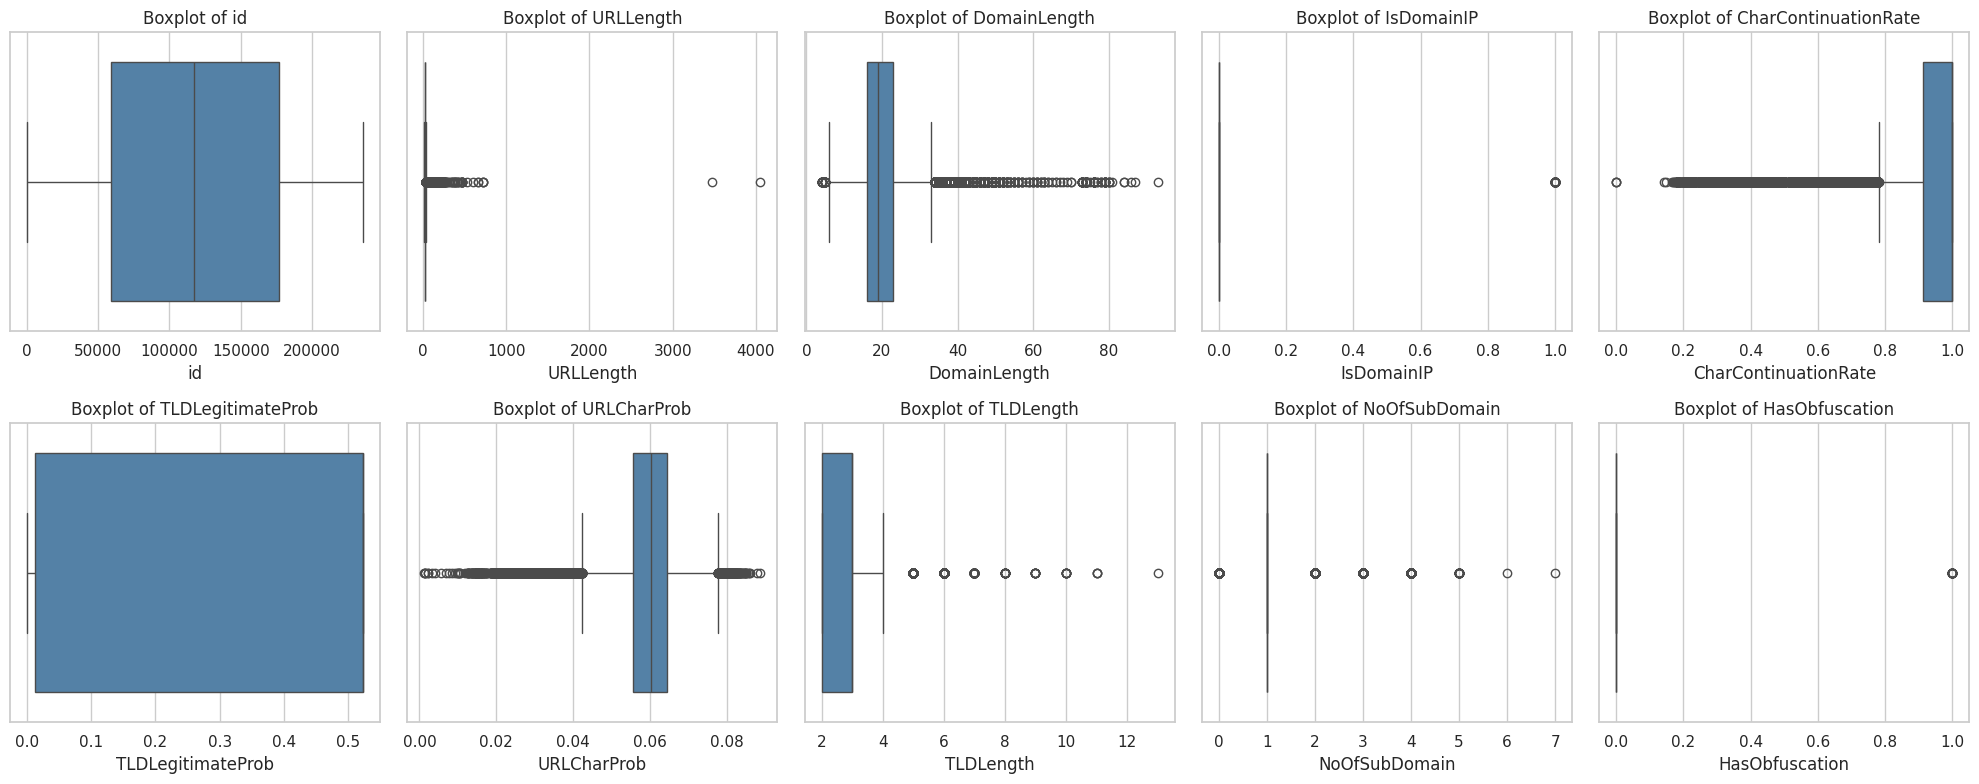

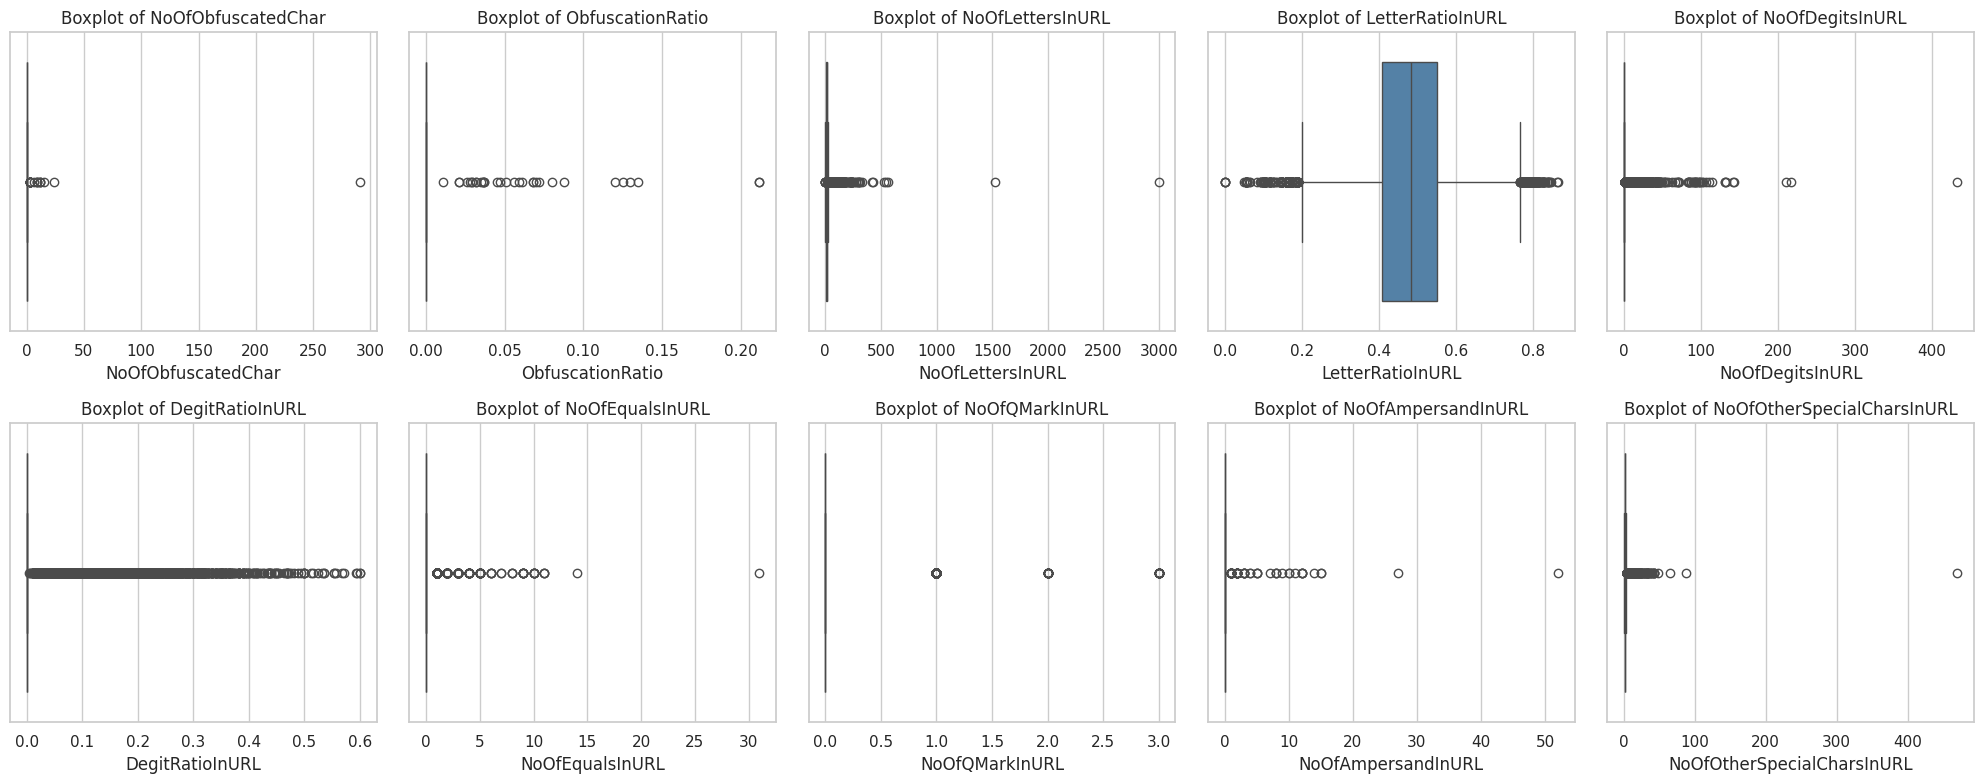

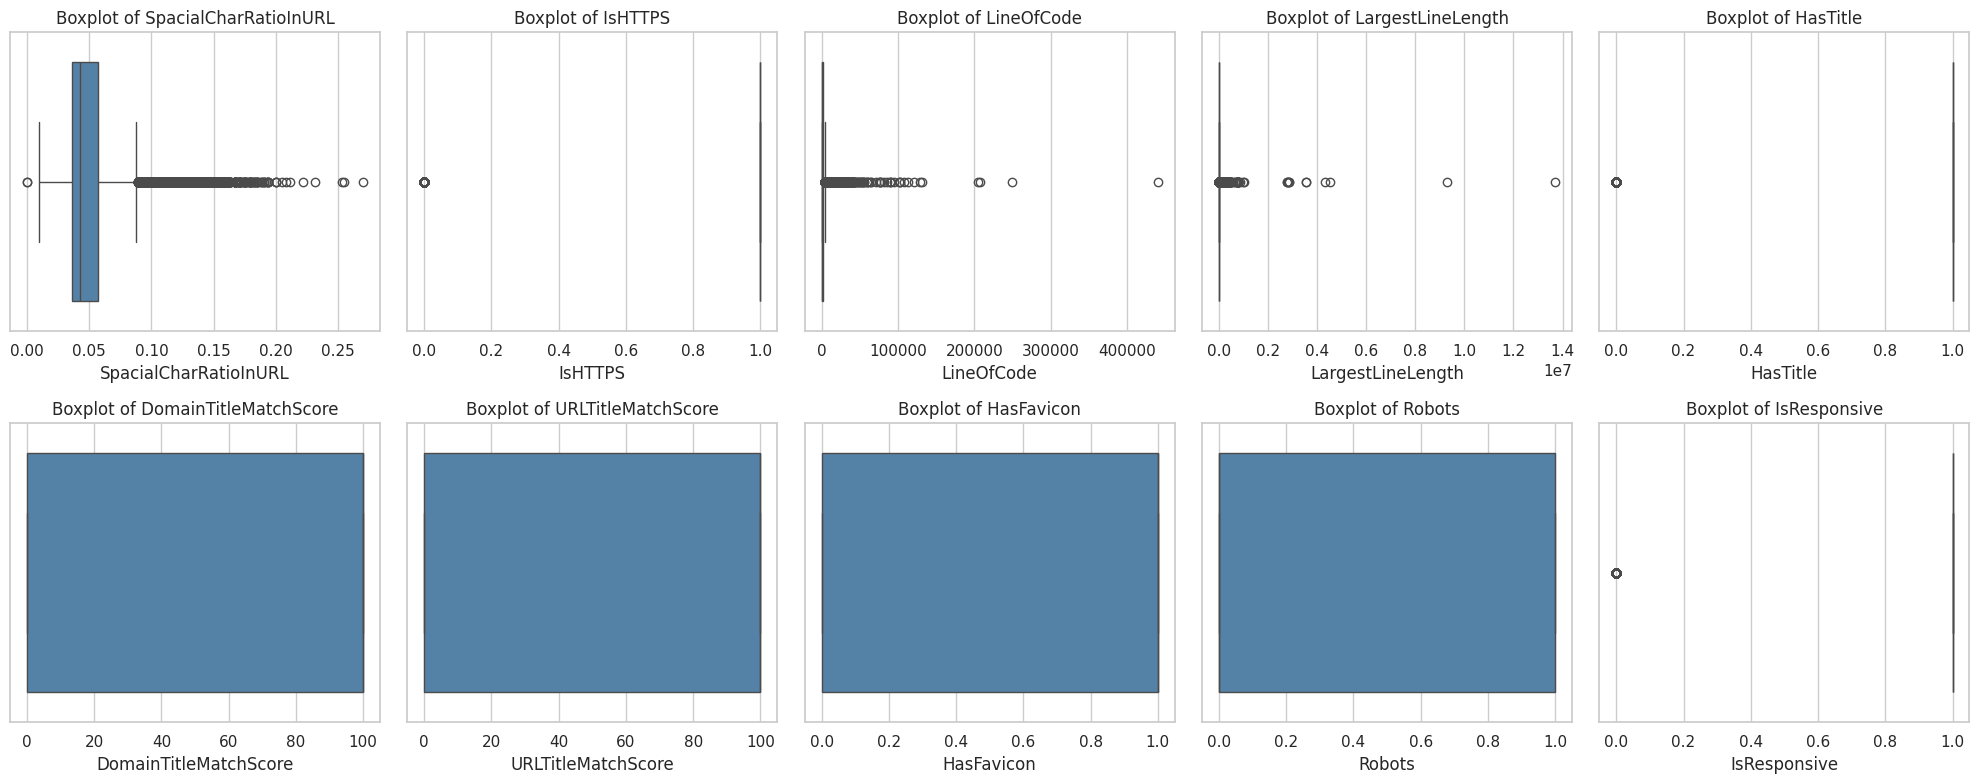

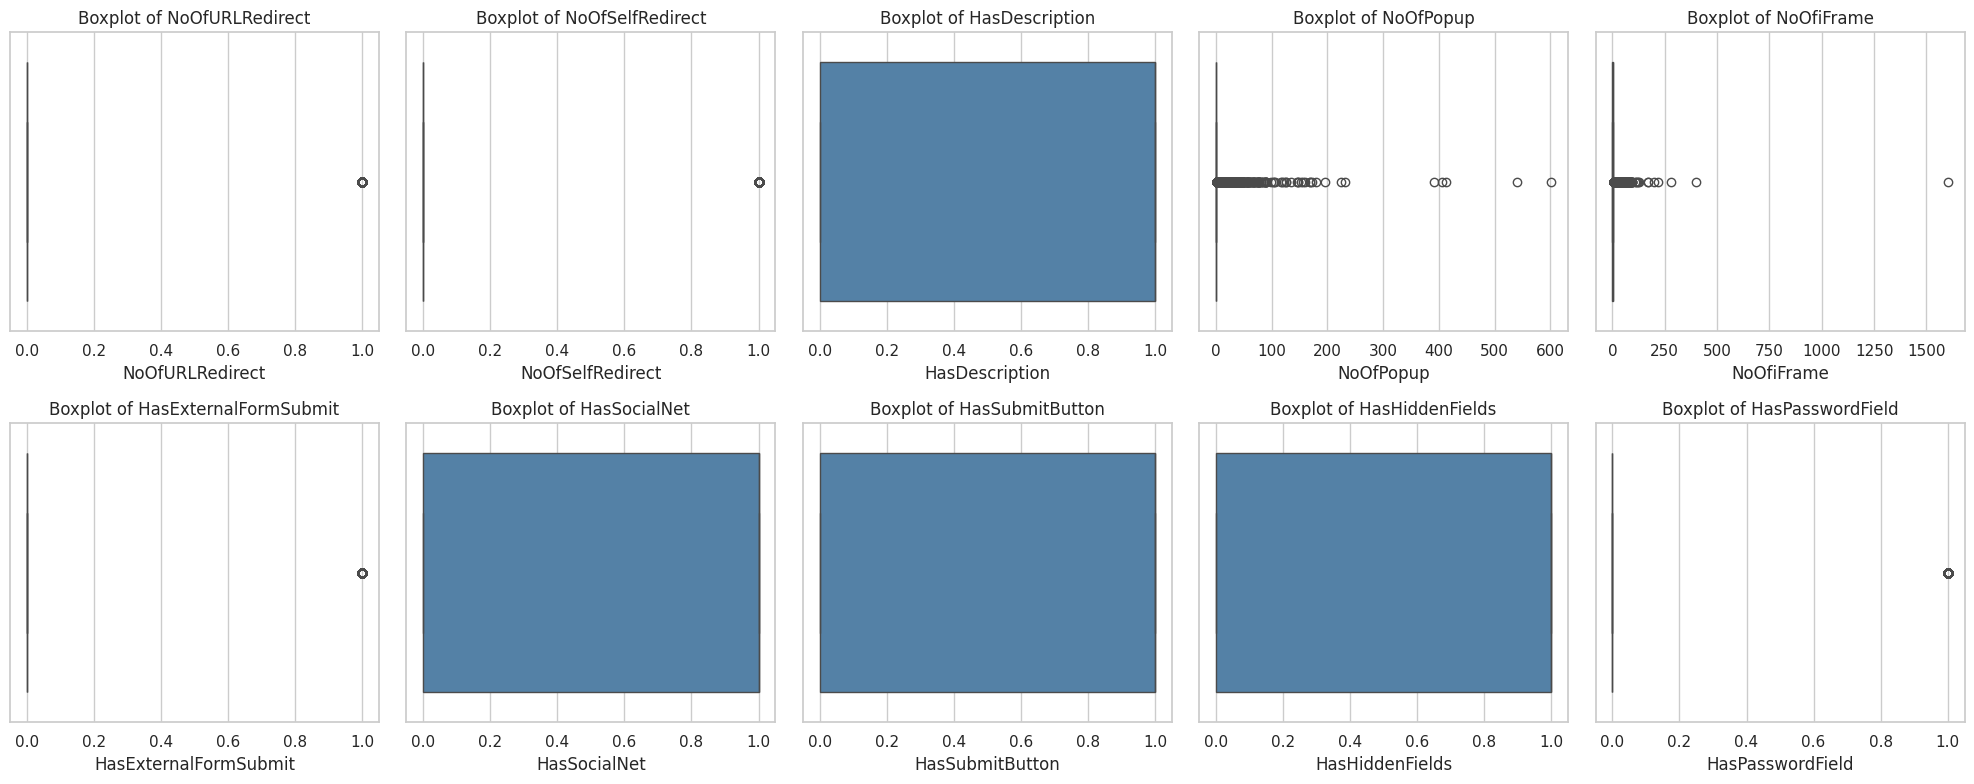

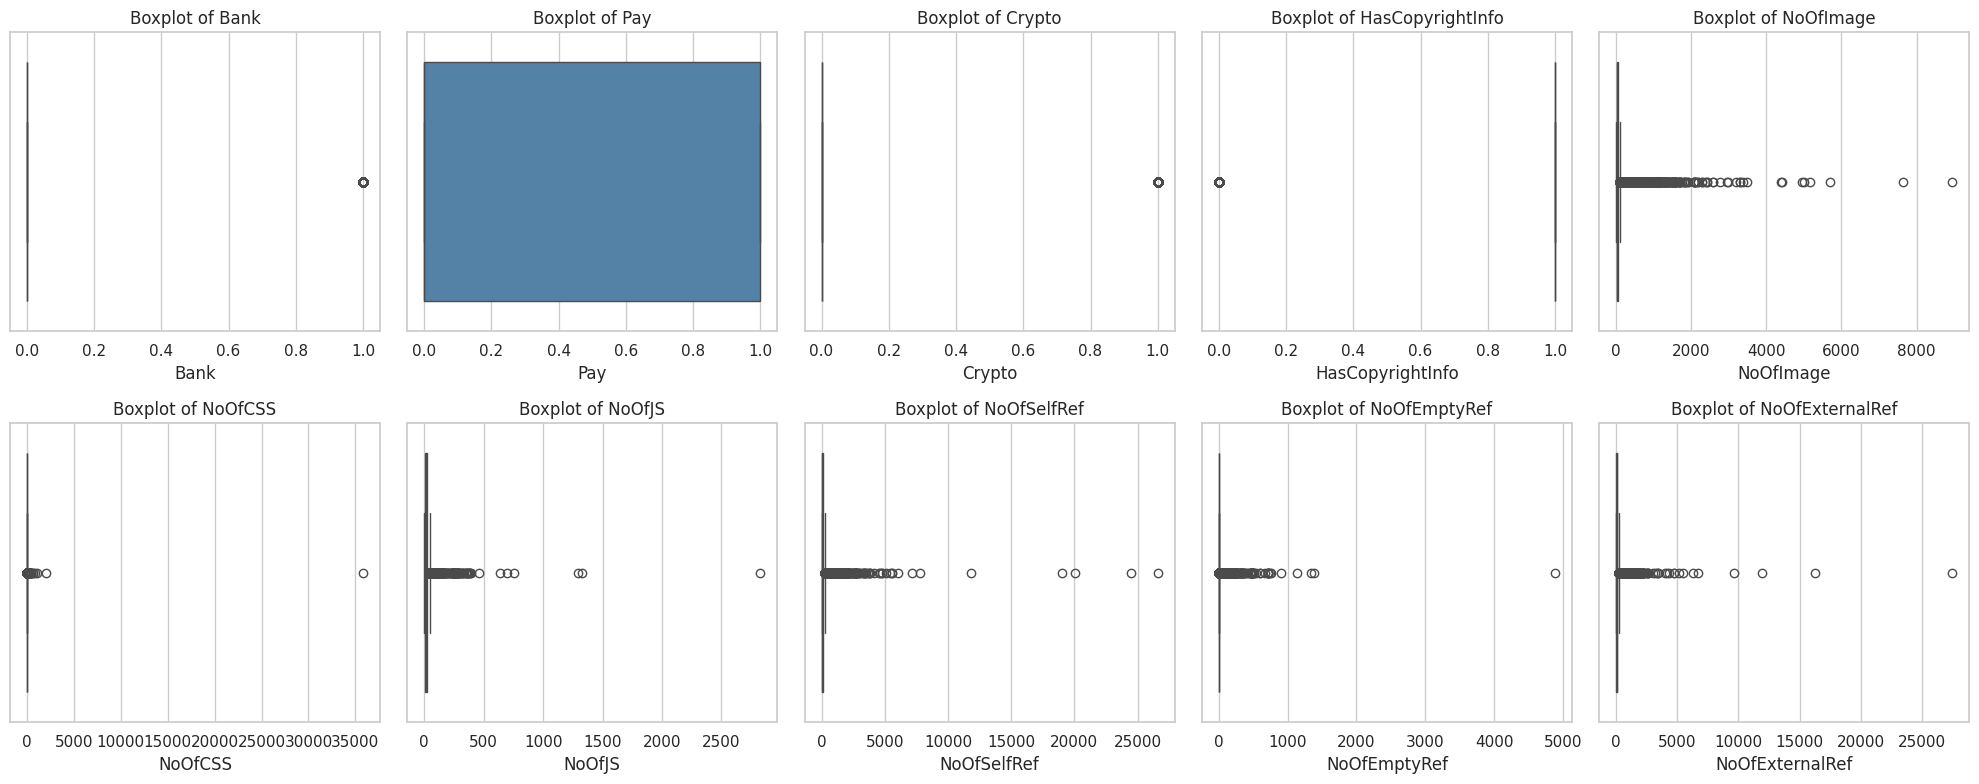

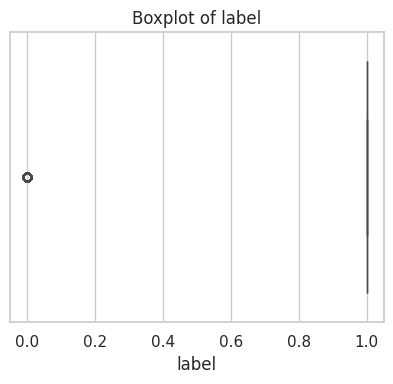

In [ ]:
import math


batch_size = 10
batches = [numerical_features[i:i + batch_size] for i in range(0, len(numerical_features), batch_size)]

for batch_idx, batch in enumerate(batches):
    rows = math.ceil(len(batch) / 5)
    fig, axes = plt.subplots(rows, 5, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(batch):
        sns.boxplot(data=df, x=col, ax=axes[i], color="steelblue")
        axes[i].set_title(f'Boxplot of {col}')


    for j in range(len(batch), len(axes)):
        fig.delaxes(axes[j])


    plt.tight_layout()
    plt.show()


# **Mengapa Penting Mengidentifikasi Missing Values dan Outliers?**

***Missing Values***
1. Analisis jadi kacau: Data kosong bikin statistik seperti rata-rata (mean) atau median salah hitung.
2. Model error: Banyak algoritma tidak bisa jalan kalau ada nilai kosong.
3. Harus di-handle: Bisa dihapus kalau sedikit, atau ganti (imputasi) menggunakan mean/median/modus.

***Outliers***
1. Ganggu statistik: Nilai ekstrem bikin rata-rata terlihat terlalu tinggi/rendah.
2. Model jadi bias: Outliers bikin prediksi tidak akurat, apalagi model yang bersifat sensitif seperti regresi.
3. Solusinya: Bisa dihapus, dibatasi *(capping)*, atau di-scale agar lebih *smooth*.

***Intinya,***

*Missing values bikin data jadi nggak lengkap → harus dilengkapi/diantisipasi.*

*Outliers bikin data jadi nggak representatif → harus dikelola biar model nggak bias.*

### Step 3

Find the following:

1. Correlations between features.
2. Visualize the distribution of each feature (categorical and continuous).
3. Visualize the correlation between features and the target variable.
4. Explain the significance of understanding feature distributions and correlations.

In [ ]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
correlation_matrix

,id,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
id,1.000000,-0.006493,-0.000968,-0.001687,0.002367,0.001894,-0.004329,0.003860,-0.001072,0.001039,...,-0.004164,0.000819,-0.003632,-0.000708,0.002246,-0.000522,0.005037,0.000219,-0.001404,0.001529
URLLength,-0.006493,1.000000,0.289682,0.204863,-0.124541,0.025708,-0.113507,0.058677,0.035948,0.278809,...,-0.015774,-0.014122,-0.071766,-0.031657,-0.038996,-0.032182,-0.066244,-0.008497,-0.029542,-0.222200
DomainLength,-0.000968,0.289682,1.000000,-0.025420,-0.299010,0.123278,-0.009943,0.124980,0.205520,0.021147,...,0.005047,-0.023233,-0.093662,-0.044093,-0.024564,-0.034124,-0.055177,-0.011112,-0.024578,-0.229585
IsDomainIP,-0.001687,0.204863,-0.025420,1.000000,-0.069108,-0.022281,-0.077555,-0.005212,0.051158,0.041227,...,-0.014882,-0.004032,-0.036001,-0.009589,-0.012179,-0.016464,-0.010751,-0.004083,-0.007852,-0.077831
CharContinuationRate,0.002367,-0.124541,-0.299010,-0.069108,1.000000,0.286157,0.227600,0.255948,-0.580155,-0.027554,...,0.098860,0.041899,0.170827,0.043894,-0.006395,0.088193,0.046358,0.012061,0.038281,0.343046
TLDLegitimateProb,0.001894,0.025708,0.123278,-0.022281,0.286157,1.000000,0.274783,0.546112,-0.375222,-0.007741,...,0.099965,0.032874,0.110946,0.037720,0.003678,0.035868,0.007764,0.006910,0.016975,0.059090
URLCharProb,-0.004329,-0.113507,-0.009943,-0.077555,0.227600,0.274783,1.000000,0.188279,-0.111008,-0.027790,...,0.082442,0.023779,0.176784,0.033906,0.012839,0.075545,0.036886,0.008380,0.033195,0.325402
TLDLength,0.003860,0.058677,0.124980,-0.005212,0.255948,0.546112,0.188279,1.000000,-0.387791,0.006696,...,0.062612,0.031639,0.012991,-0.010795,0.001635,-0.004661,-0.034367,-0.014124,-0.009297,-0.042523
NoOfSubDomain,-0.001072,0.035948,0.205520,0.051158,-0.580155,-0.375222,-0.111008,-0.387791,1.000000,0.016604,...,-0.020941,-0.027890,-0.012473,-0.014541,-0.001196,-0.006503,0.007463,0.004016,0.005381,-0.007165
HasObfuscation,0.001039,0.278809,0.021147,0.041227,-0.027554,-0.007741,-0.027790,0.006696,0.016604,1.000000,...,-0.010529,0.002020,-0.019304,-0.007699,-0.009245,-0.012040,-0.011773,-0.002239,-0.006126,-0.069725


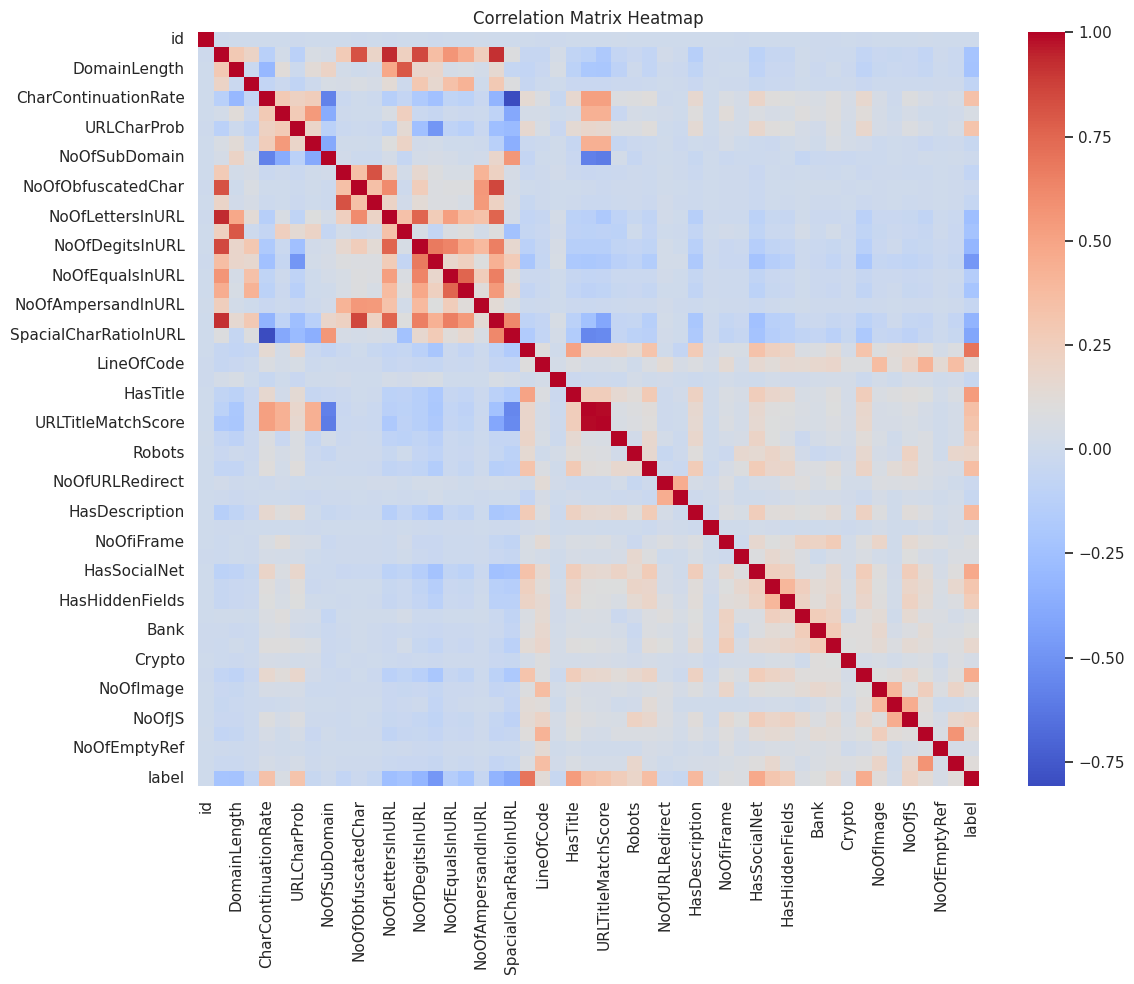

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

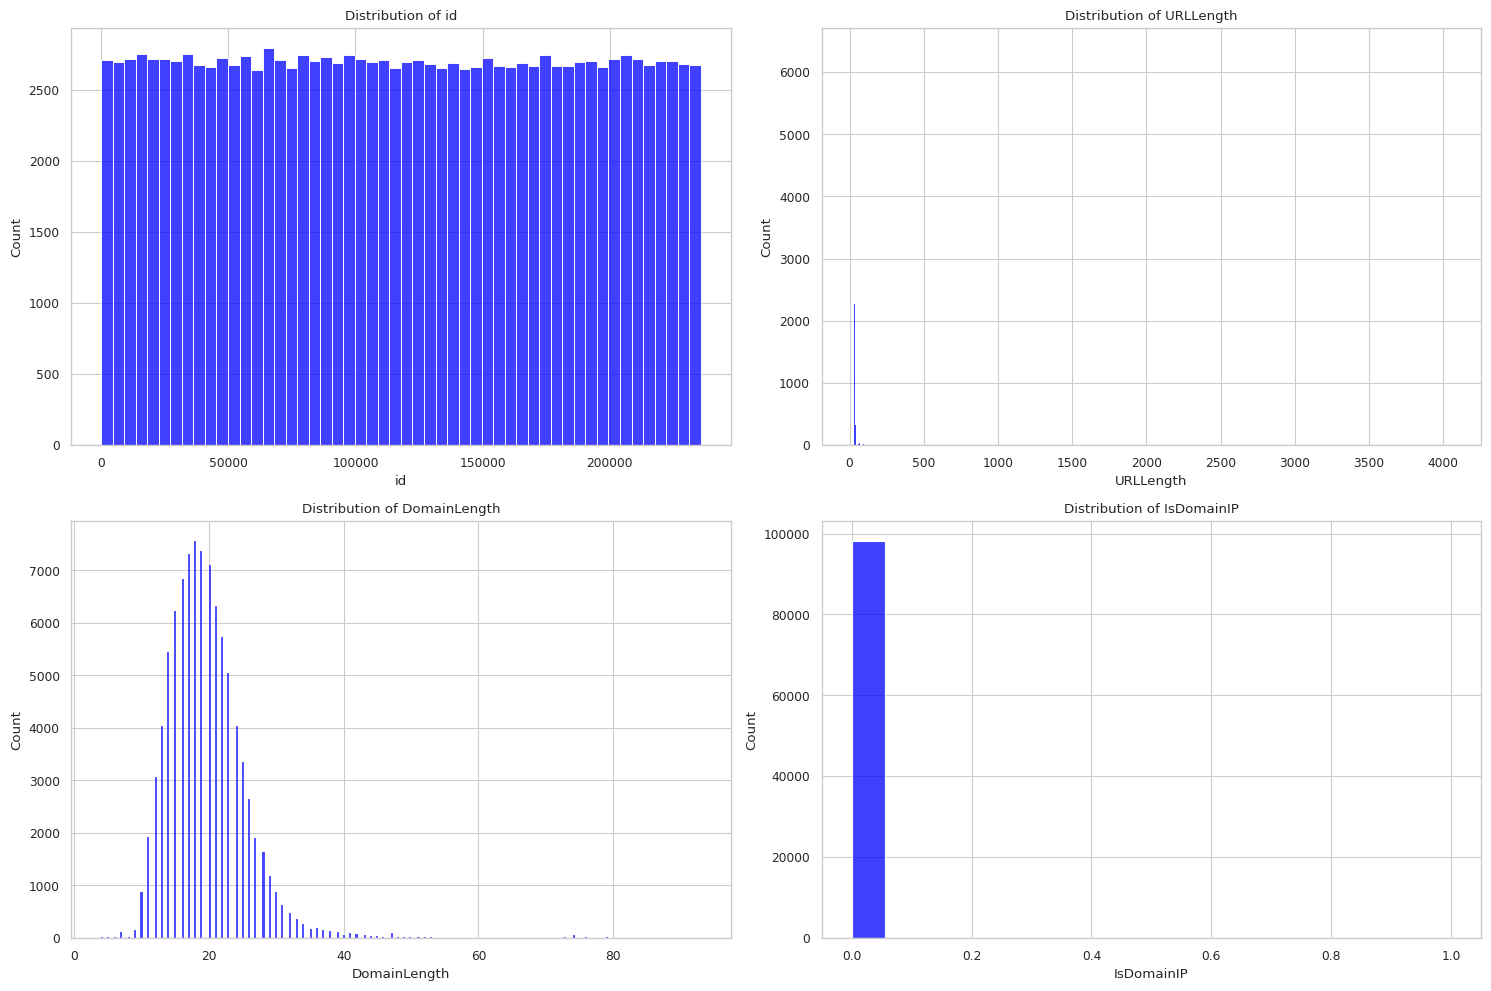

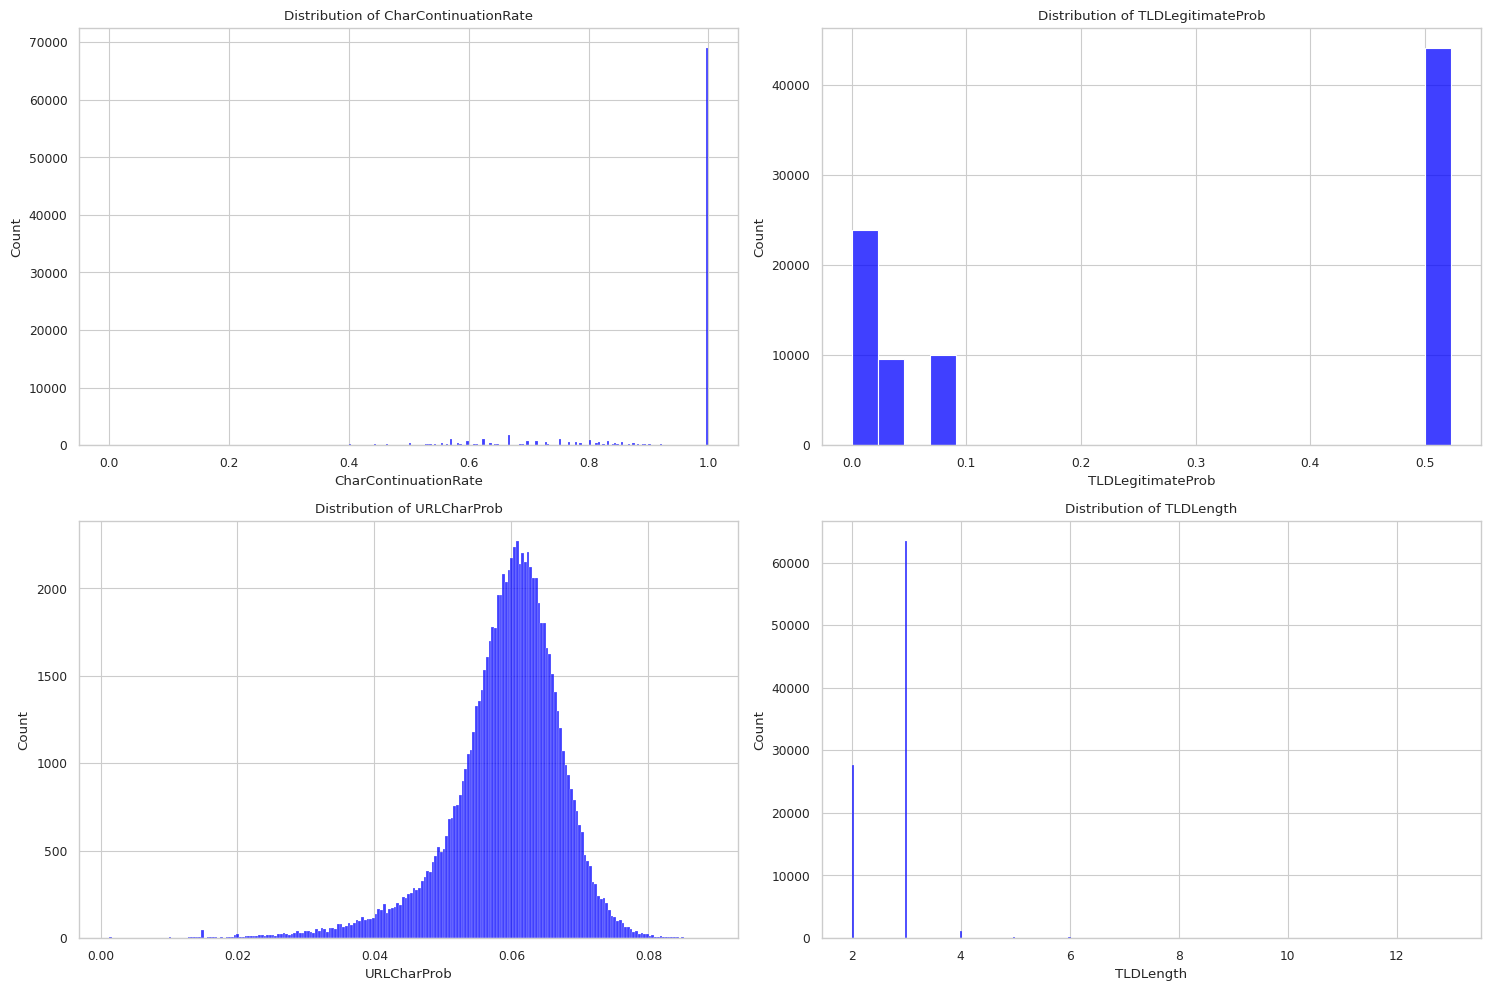

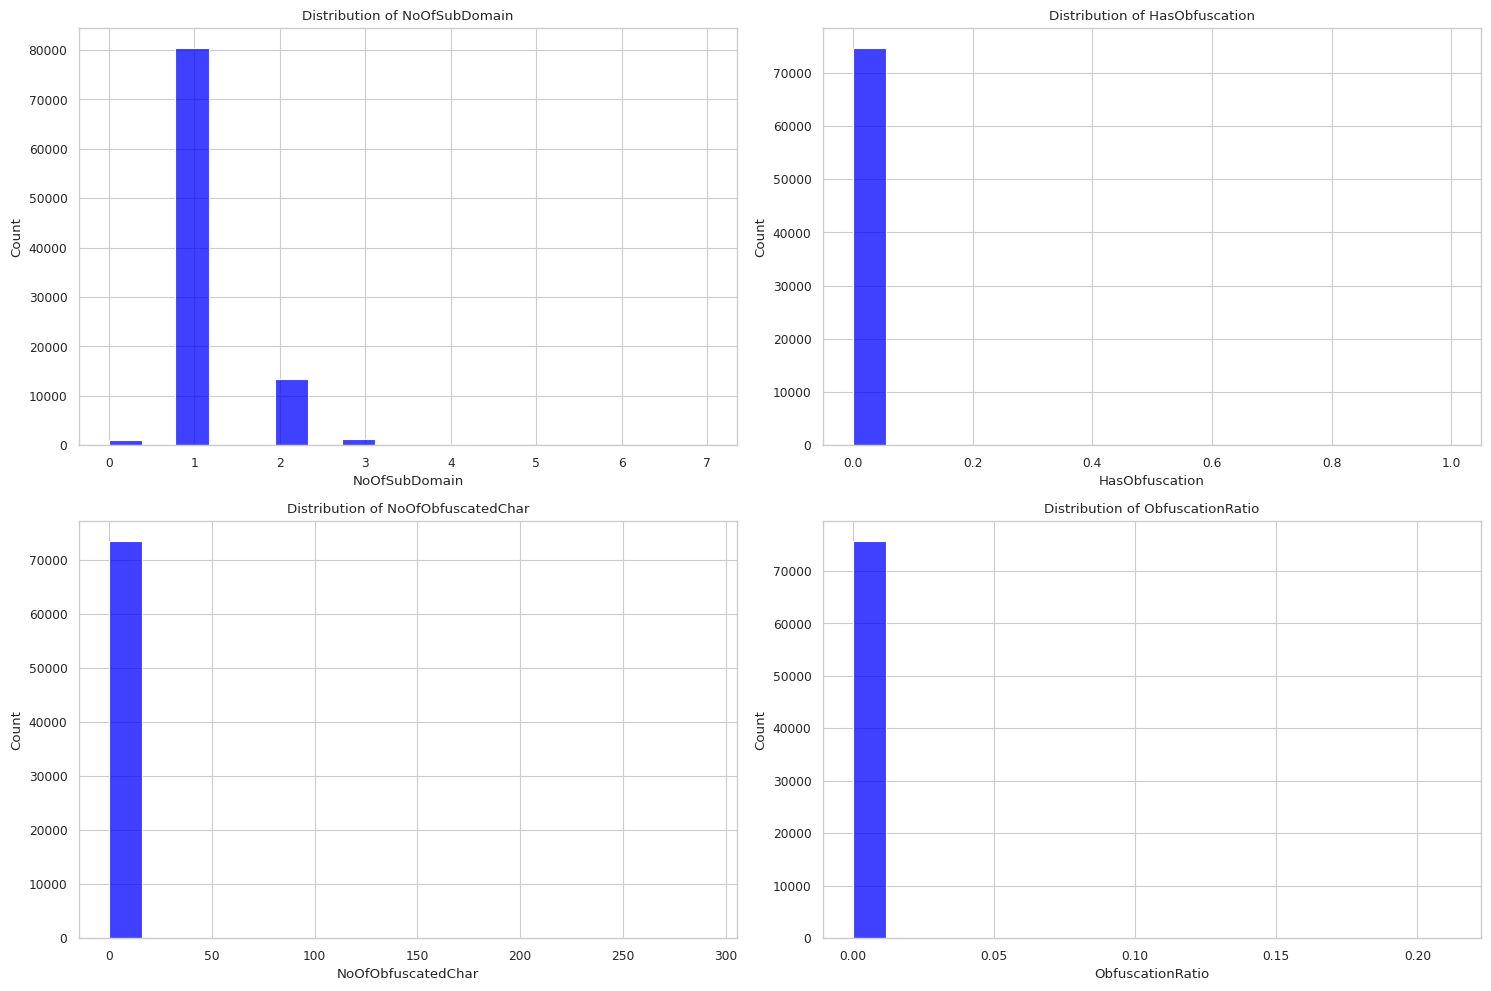

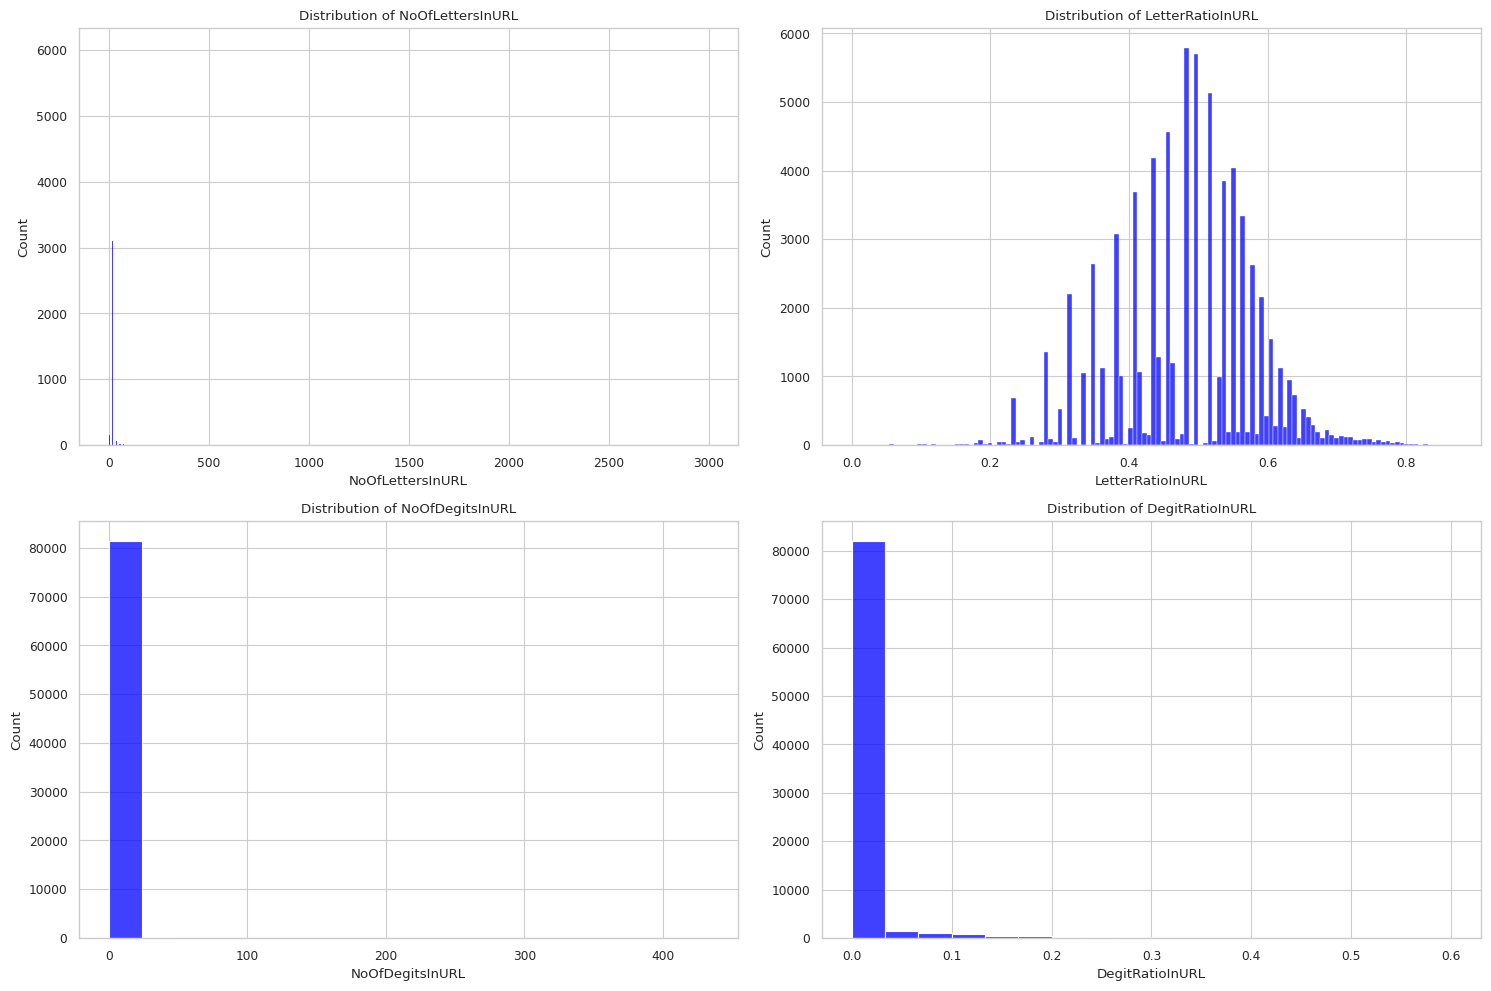

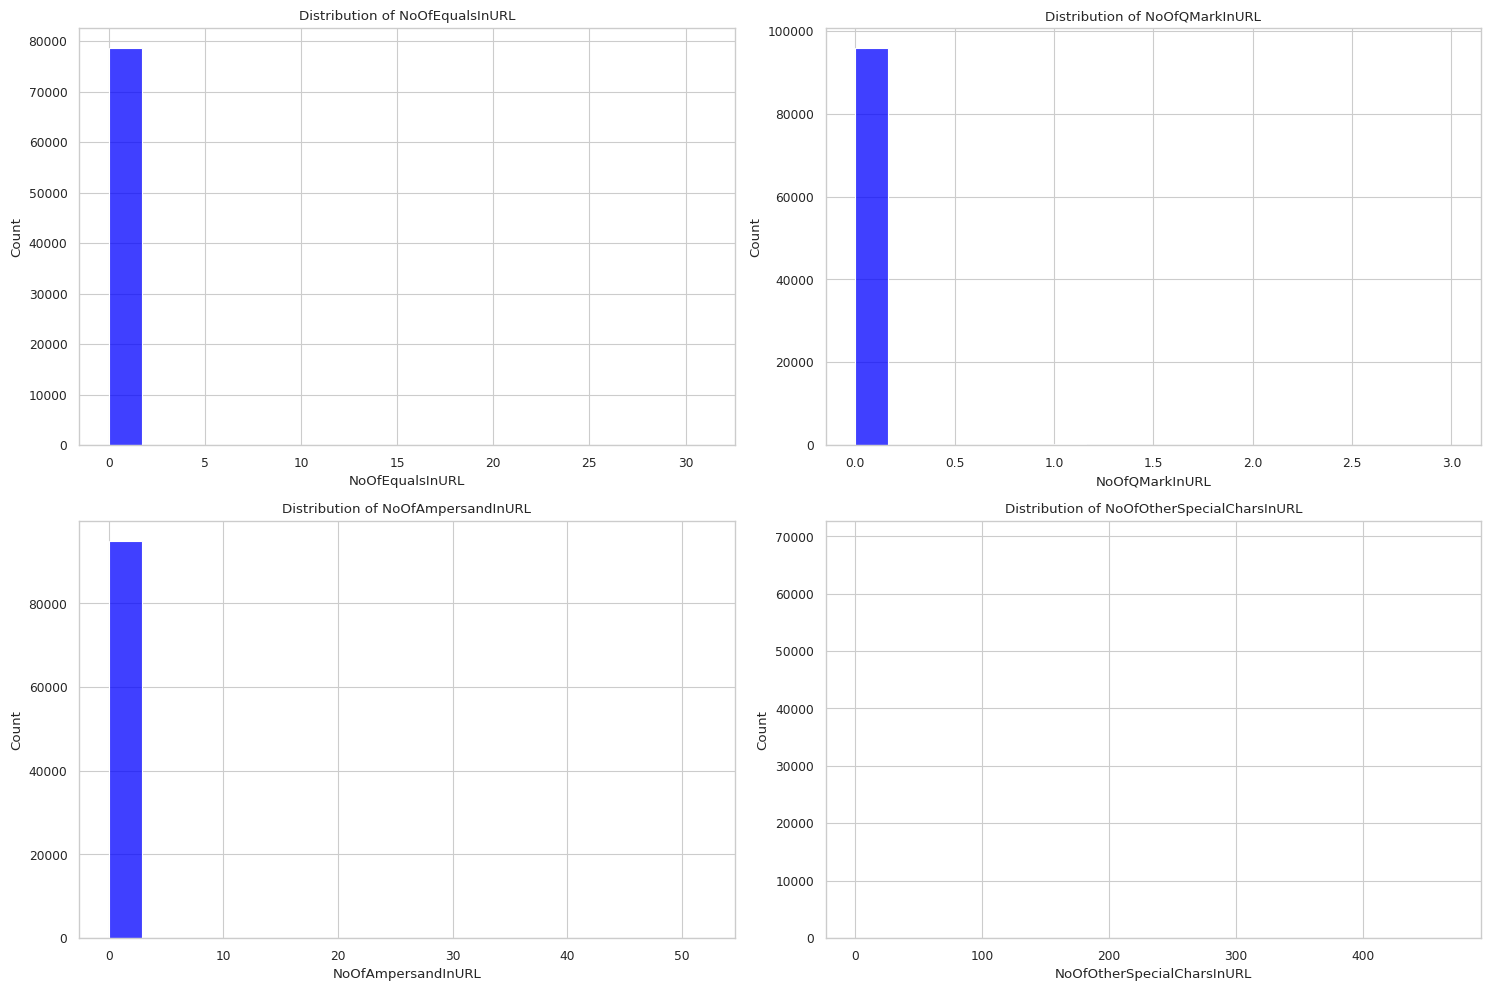

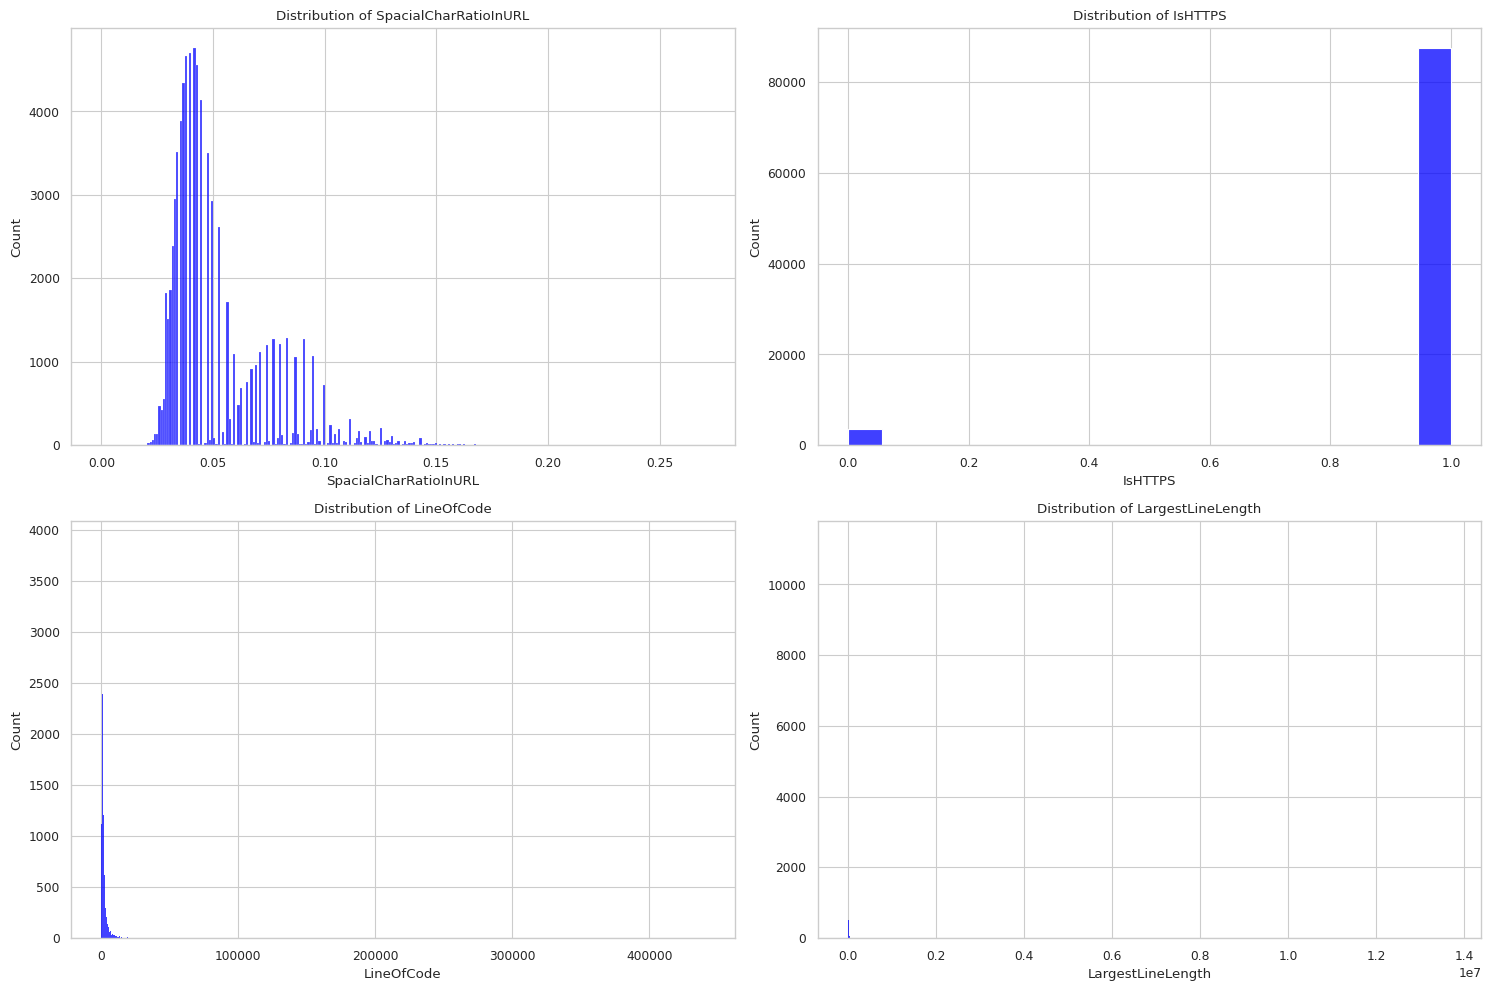

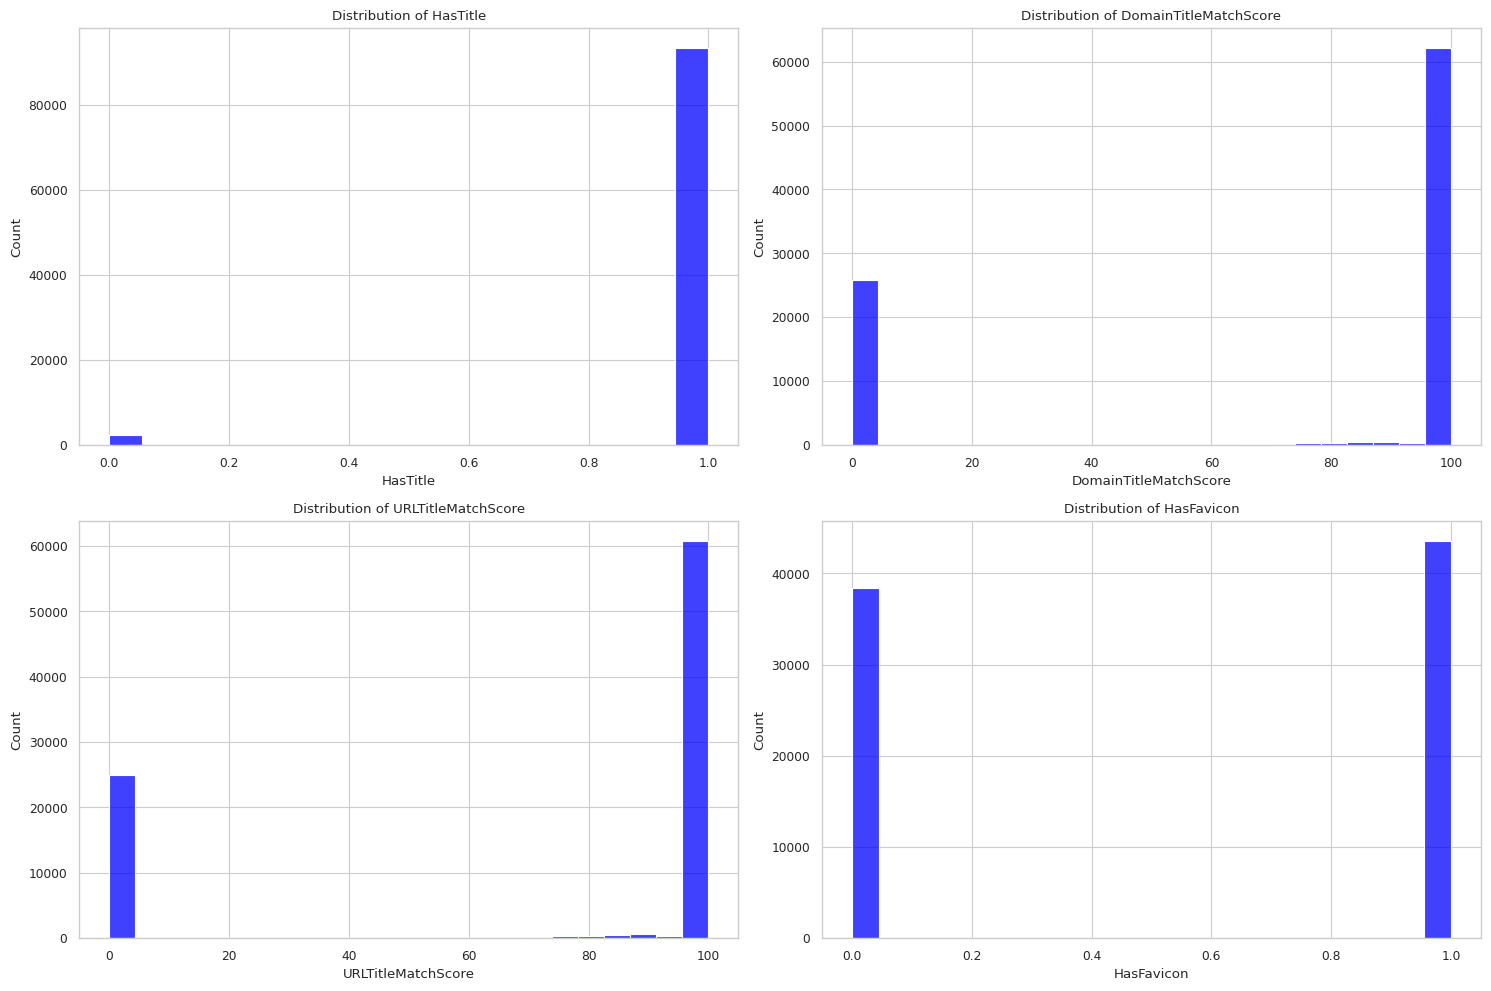

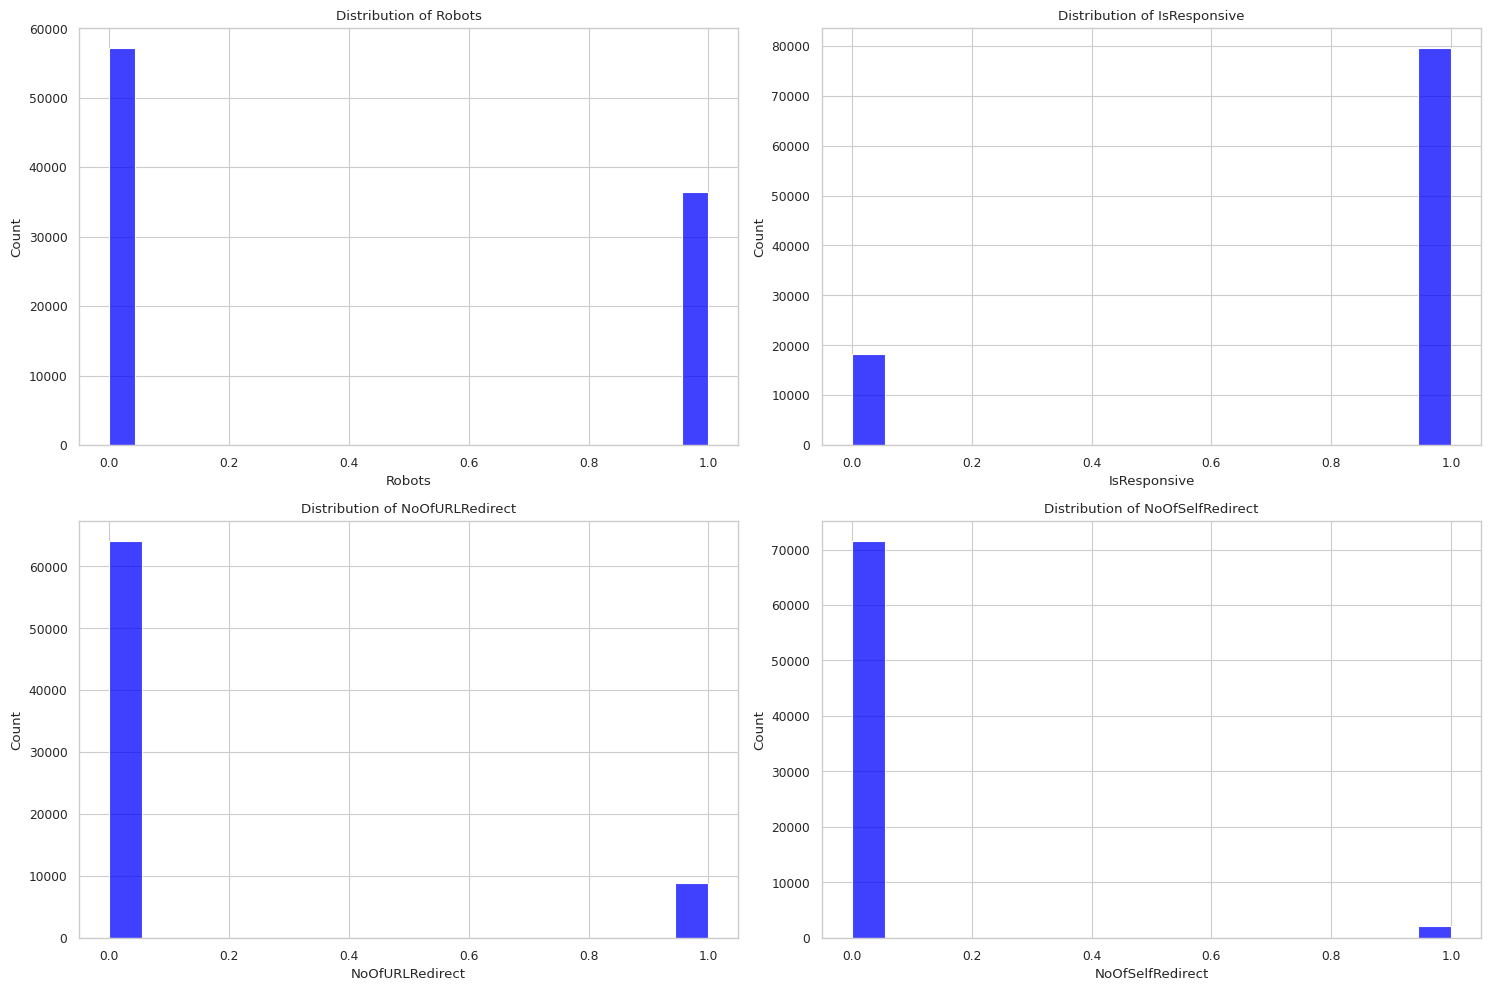

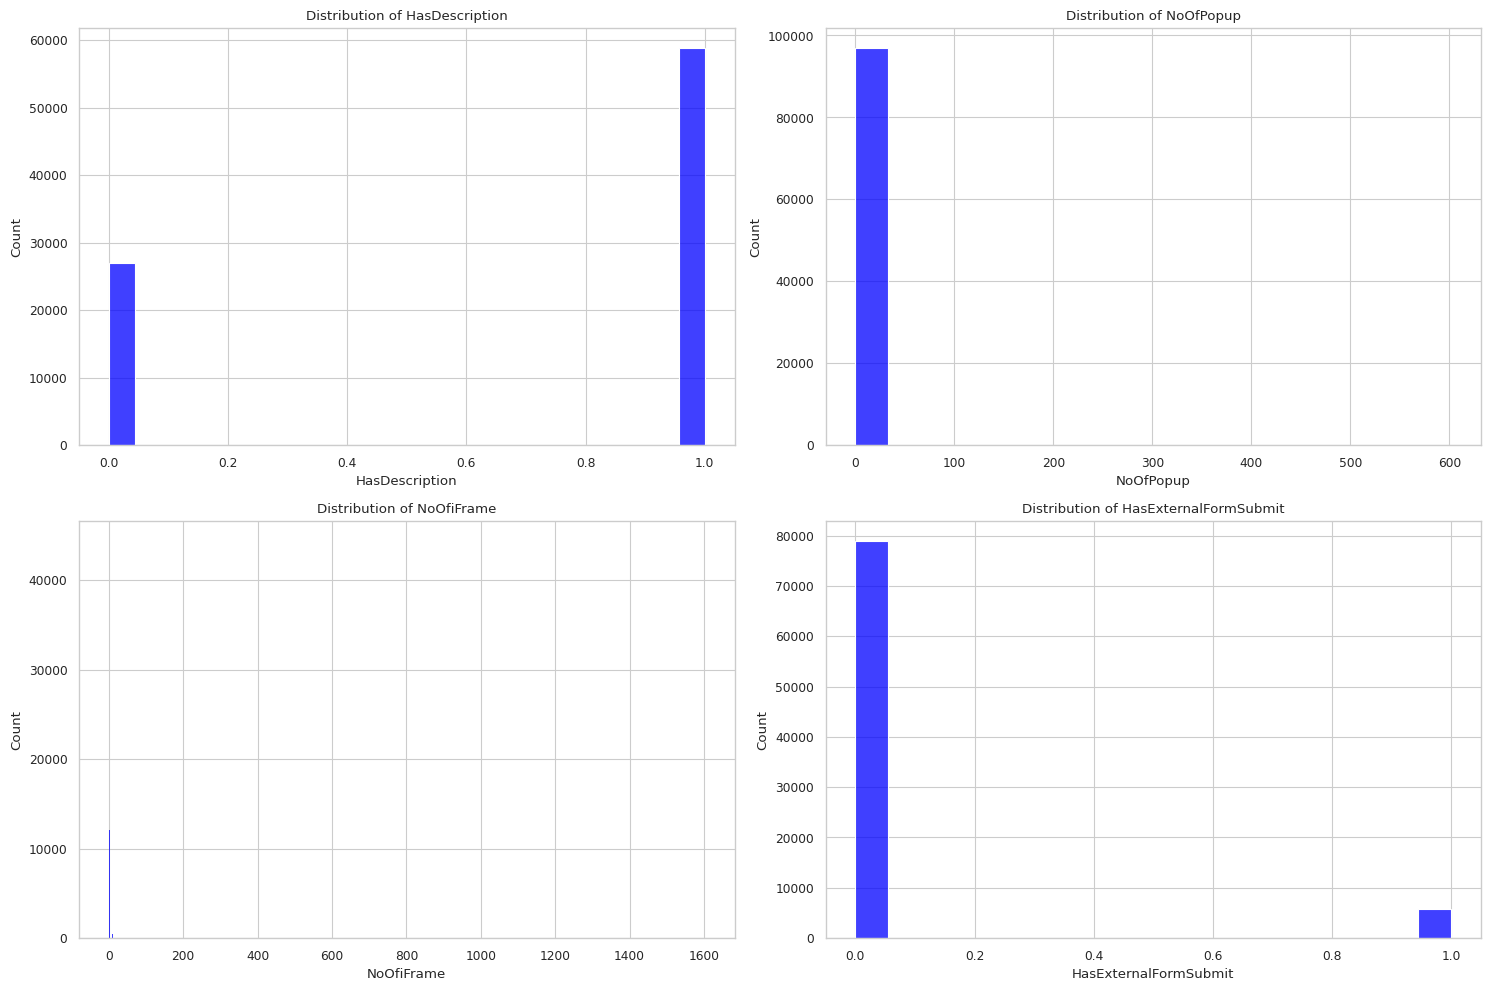

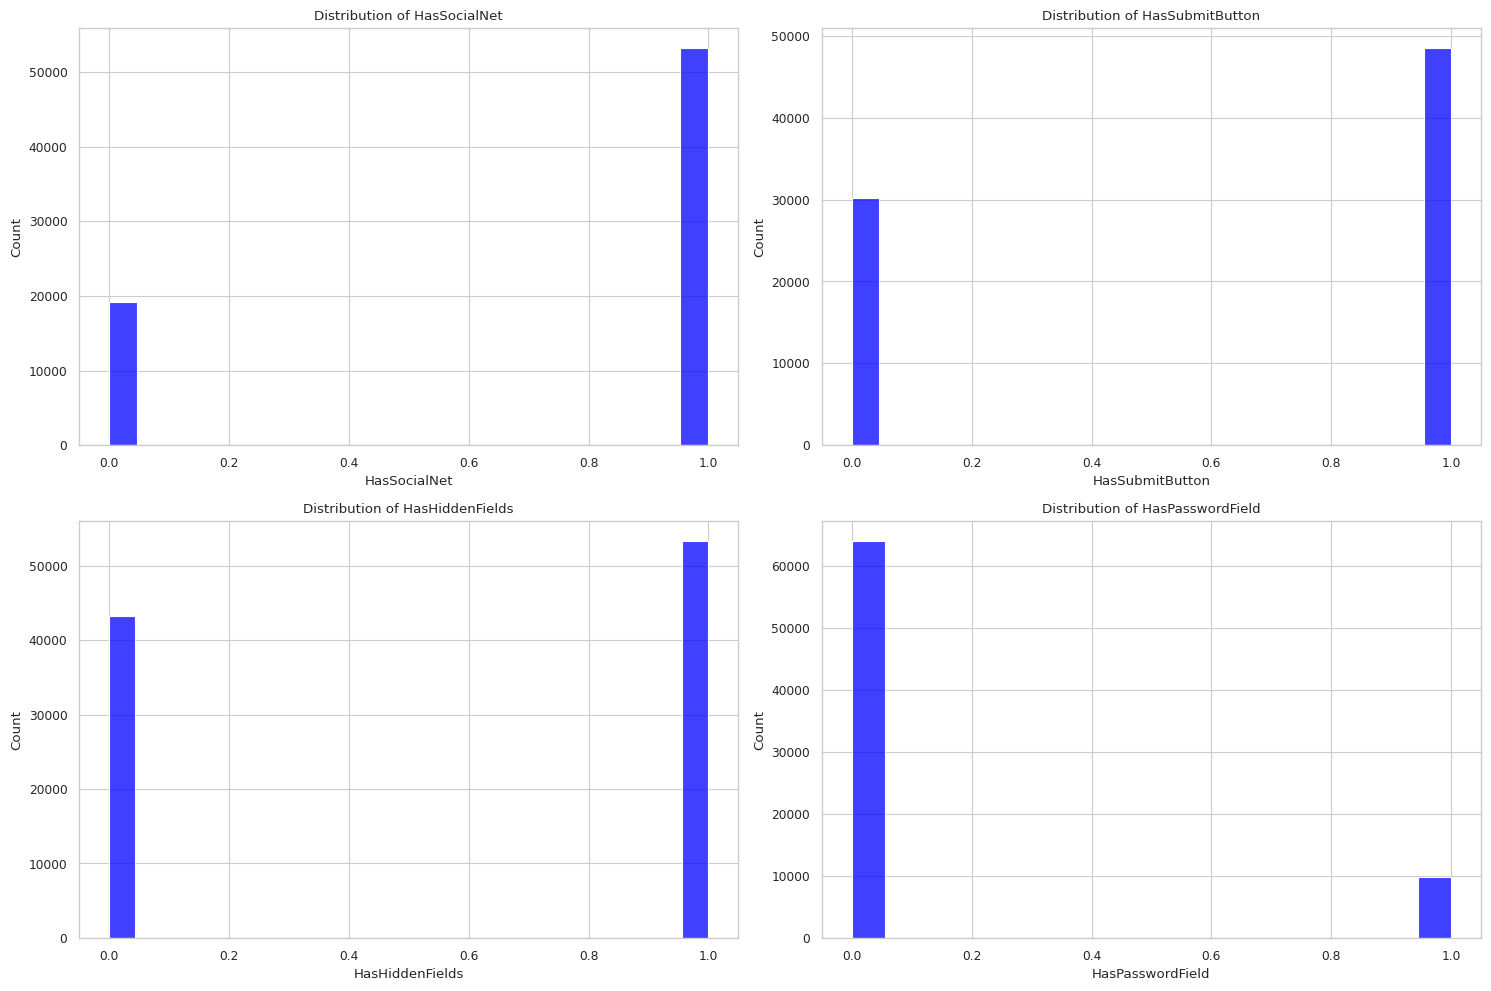

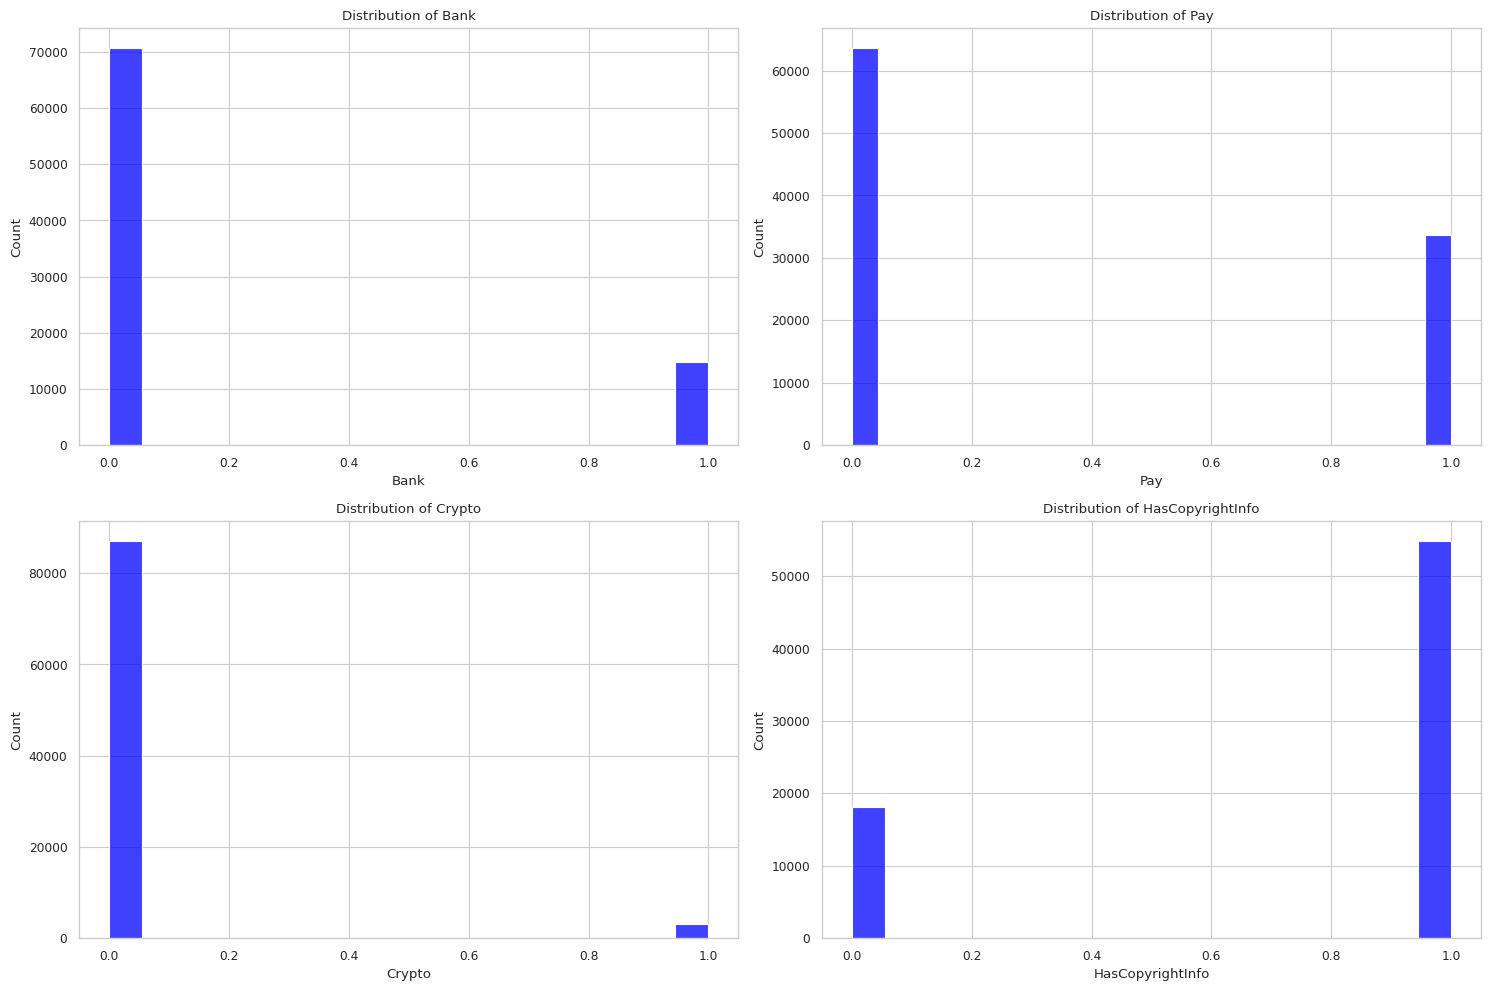

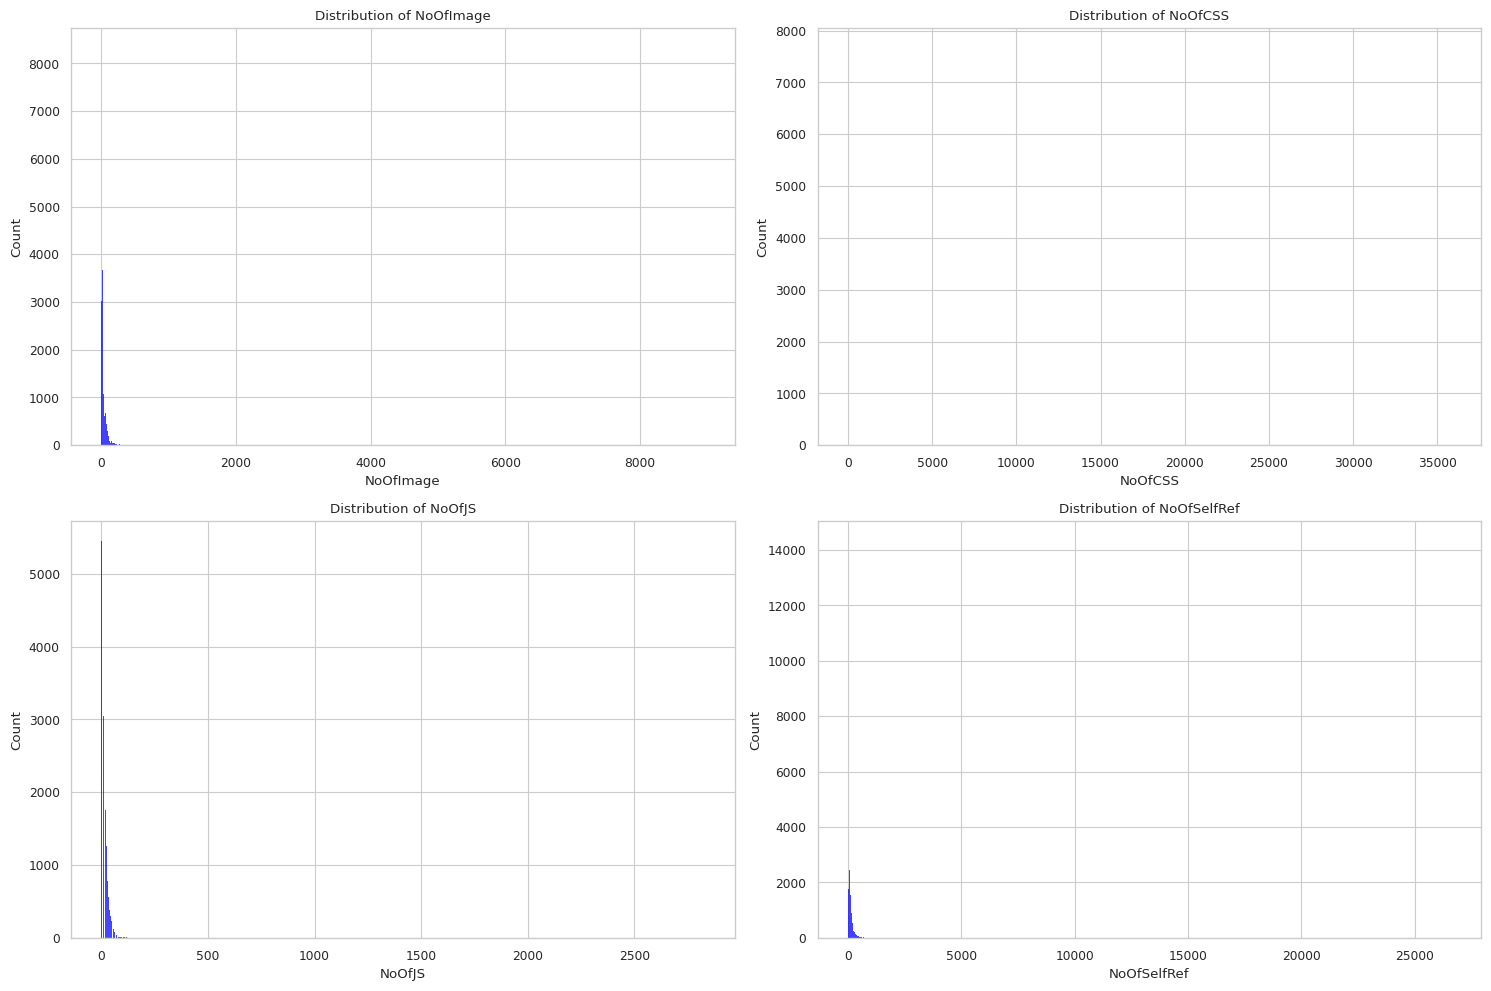

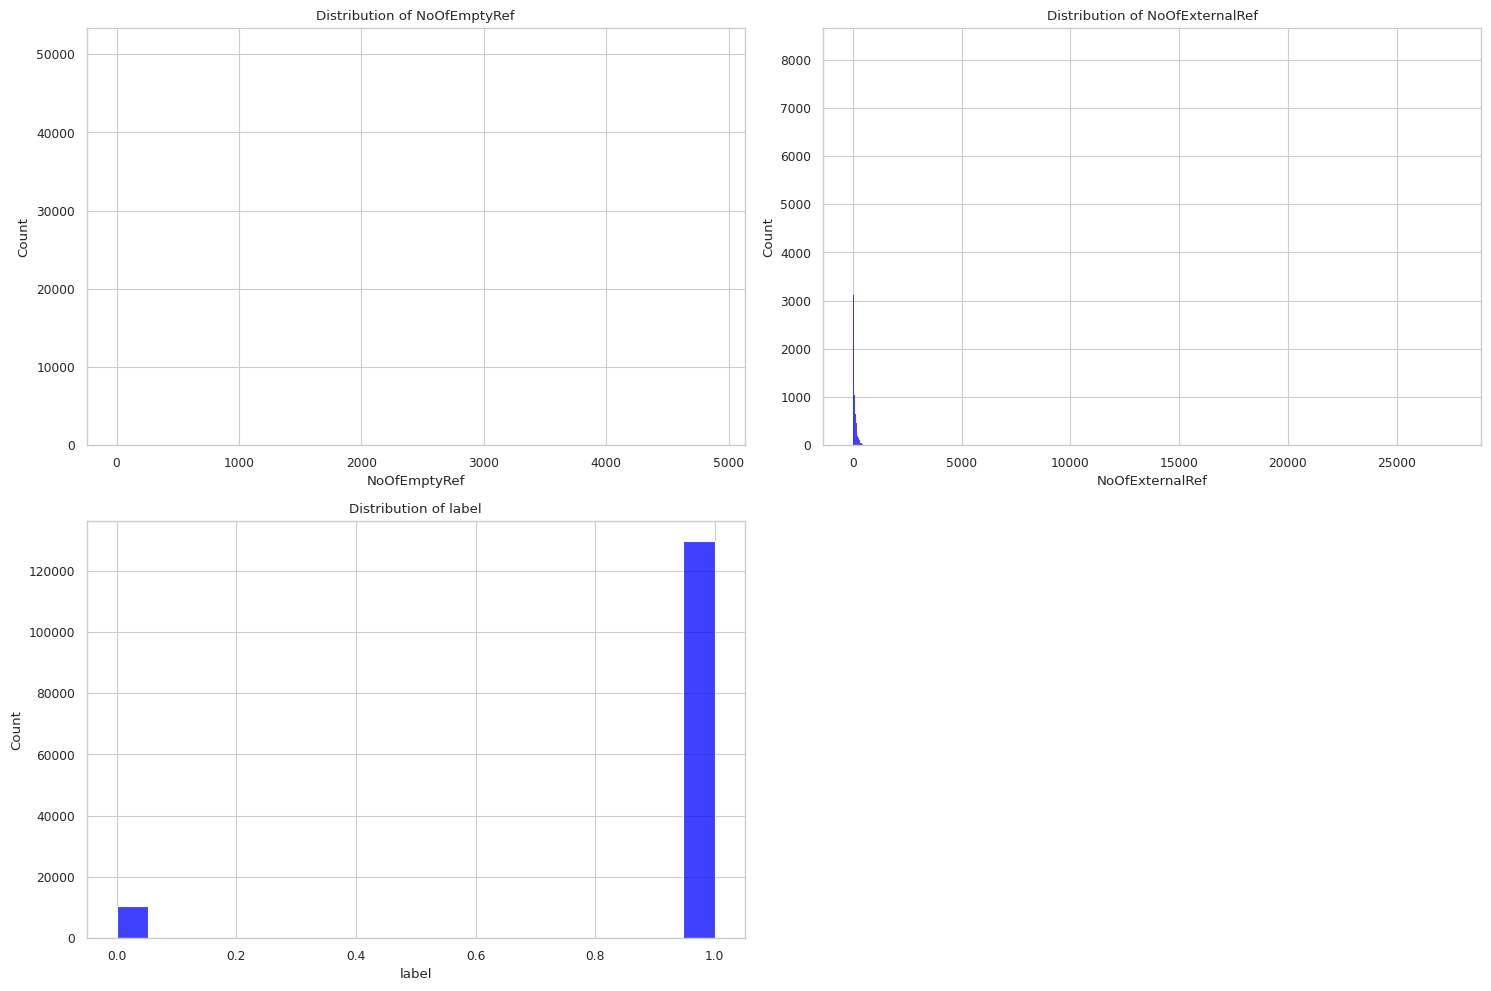

In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist() # ini termasuk fitur yang aslinya bisa disebut kategorikal tapi valuenya int64 atau float64 yang nilainya 0 dan 1 yang mewakili ya atau tidak, secara logis ini dianggpa sebagai fitur kategorikal

def plot_numerical_distributions(df, numeric_features):
    for i in range(0, len(numeric_features), 4):
        fig, ax = plt.subplots(2, 2, figsize=(15, 10))
        sns.set_style('whitegrid')
        sns.set_context('paper', font_scale=1)
        axes = ax.flatten()

        for j, feature in enumerate(numeric_features[i:i+4]):
            sns.histplot(df[feature], ax=axes[j], kde=False, stat="count", color="blue")
            axes[j].set_title(f"Distribution of {feature}")
            axes[j].set_ylabel("Count")
            axes[j].set_xlabel(feature)


        for k in range(len(numeric_features[i:i+4]), 4):
            axes[k].set_visible(False)

        plt.tight_layout()
        plt.show()

plot_numerical_distributions(df, numeric_features)

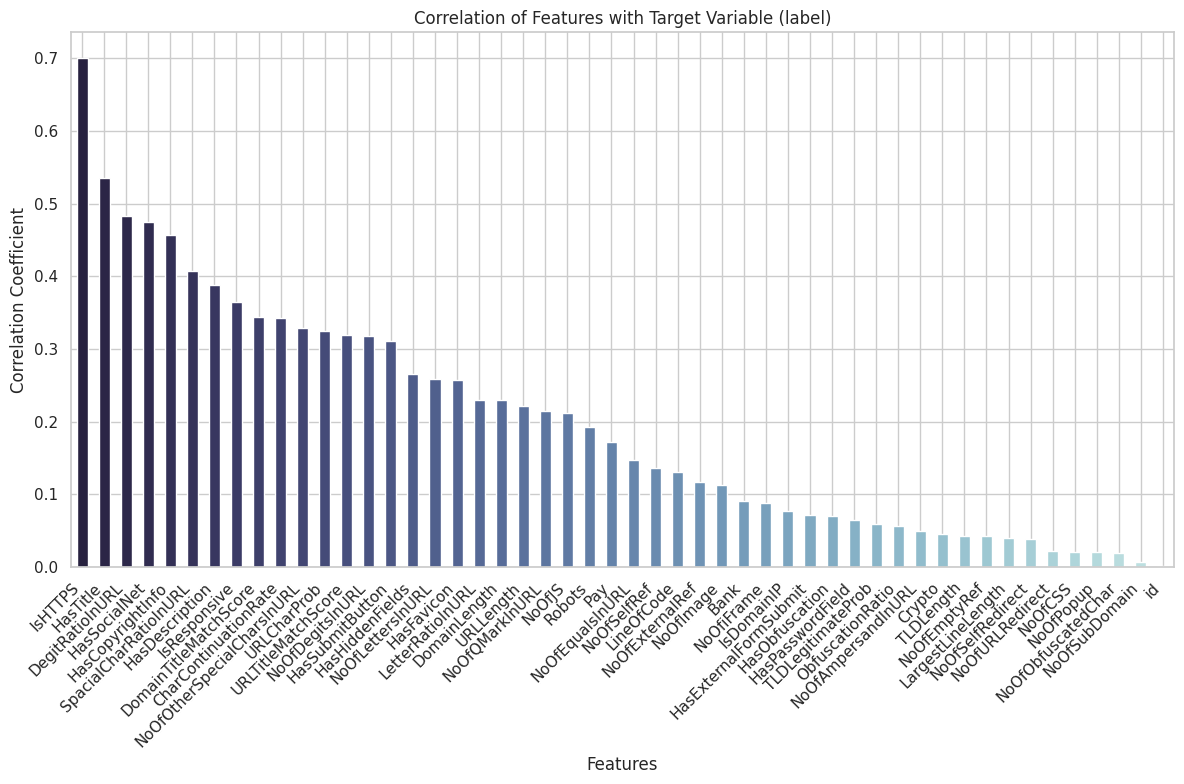

In [ ]:
numeric_df = df.select_dtypes(include=['number'])


target_corr = numeric_df.corr()['label'].drop('label')

# Urutkan dari yang terbesar
sorted_corr = target_corr.abs().sort_values(ascending=False)


plt.figure(figsize=(12, 8))
sorted_corr.plot(kind='bar', color=sns.color_palette("ch:start=0.2,rot=-.3_r", len(sorted_corr)))
plt.title("Correlation of Features with Target Variable (label)")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Memahami distribusi dan korelasi fitur adalah hal yang penting dalam analisis data dan pengembangan model ML. Distribusi fitur membantu mengidentifikasi skewness yang dapat memengaruhi kinerja model. Selain itu, distribusi juga membantu mendeteksi outlier yang dapat mendistorsi hasil model, dan penanganan seperti penghapusan atau imputasi. Pola data yang hilang atau bernilai nol juga dapat terlihat dari distribusi, sehingga mempermudah strategi imputasi atau rekayasa fitur. Untuk fitur kategori, memahami frekuensi nilai memungkinkan pemilihan metode encoding yang tepat, seperti one-hot atau ordinal encoding.

Korelasi antar fitur juga sangat penting karena dapat mengungkap adanya multikolinearitas, yaitu korelasi tinggi antar variabel independen yang dapat meningkatkan variansi model. Dengan memahami korelasi, kita dapat melakukan pemilihan fitur atau reduksi dimensi menggunakan teknik seperti PCA. Korelasi dengan variabel target mengidentifikasi fitur dengan daya prediktif tinggi, yang sangat membantu dalam optimisasi model. Selain itu, korelasi antar fitur dapat menunjukkan potensi interaksi yang jika ditangkap, dapat meningkatkan kompleksitas dan kinerja model.Visualisasi sering kali memperlihatkan kesalahan data, seperti tipe data yang salah atau pola yang tidak biasa, sehingga perbaikan dapat dilakukan sebelum pemodelan. Dengan memahami distribusi dan korelasi fitur, pengambilan keputusan menjadi lebih tepat, kinerja model meningkat, dan hasil yang diperoleh lebih baik.



## B. Data Insights

The objective of this section is for participants to understand how to formulate and get many insights from the given data so that we can improve the model performance. Given example questions:

1. How was the proportion between phishing and non-phishing URLs on security related features (`IsHTTPS` and `Robots`)?
2. Is there a significant correlation between the label of a URL (phishing or non-phishing) and its URL characteristics?
3. How does website-resource-related features vary across phishing and non-phishing URLs?

### Step 1

Answer the three example questions by visualizing and explaining the insights for each question. Add markdown texts to explain the visualizations.

#### 1. How was the proportion between phishing and non-phishing URLs on security related features (`IsHTTPS` and `Robots`)?

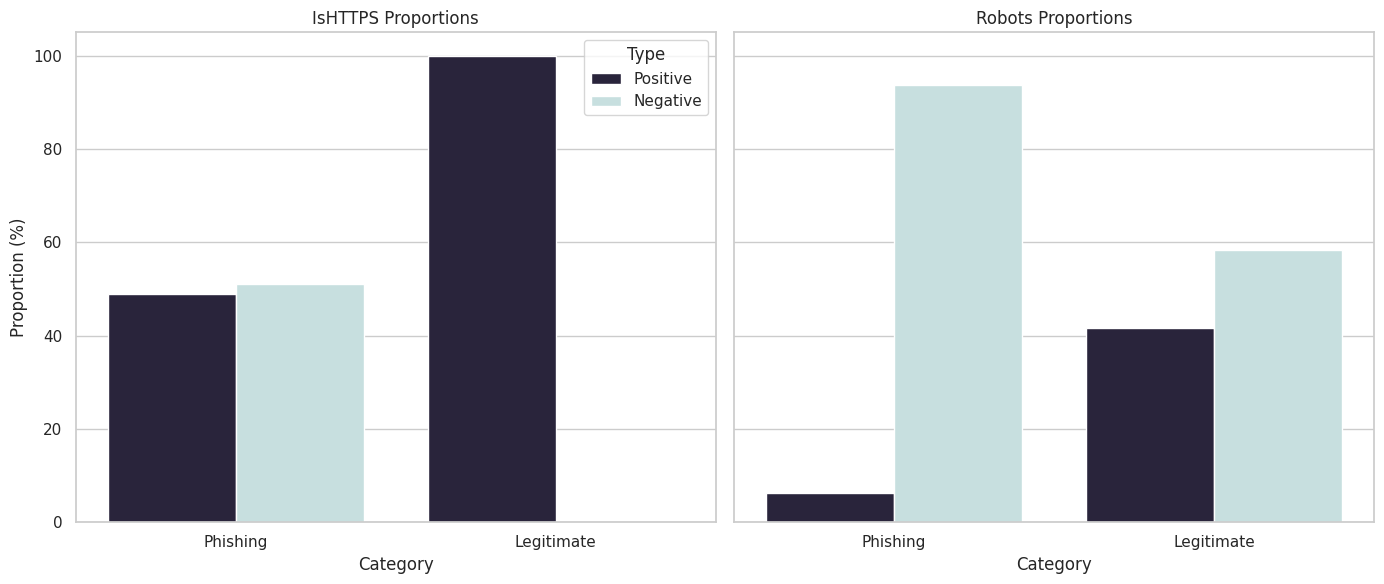

In [ ]:
# Menghitung total jumlah URL phishing dan legitimate untuk fitur IsHTTPS dan Robots
total_counts = df.groupby('label')[['IsHTTPS', 'Robots']].count()
feature_counts = df.groupby('label')[['IsHTTPS', 'Robots']].sum()

# Menggabungkan total dan proporsi untuk tampilan yang lengkap
full_proportion_data = feature_counts.copy()
full_proportion_data['IsHTTPS_Proportion'] = (feature_counts['IsHTTPS'] / total_counts['IsHTTPS']) * 100
full_proportion_data['Robots_Proportion'] = (feature_counts['Robots'] / total_counts['Robots']) * 100

# Mengubah indeks agar lebih mudah dibaca
full_proportion_data.index = ['Phishing', 'Legitimate']


detailed_stats = pd.DataFrame()
features = ['IsHTTPS', 'Robots']

# perhitungan statistik untuk setiap fitur
for feature in features:
    total = df.groupby('label')[feature].count()
    positive = df.groupby('label')[feature].sum()
    proportion_positive = (positive / total) * 100
    proportion_negative = 100 - proportion_positive


    stats = pd.DataFrame({
        f'{feature}_Total': total,
        f'{feature}_Positive_Count': positive,
        f'{feature}_Positive_Proportion (%)': proportion_positive,
        f'{feature}_Negative_Proportion (%)': proportion_negative
    })

    detailed_stats = pd.concat([detailed_stats, stats], axis=1)


detailed_stats.index = ['Phishing', 'Legitimate']
plot_data = detailed_stats.reset_index().melt(id_vars='index', value_vars=[
    'IsHTTPS_Positive_Proportion (%)', 'IsHTTPS_Negative_Proportion (%)',
    'Robots_Positive_Proportion (%)', 'Robots_Negative_Proportion (%)'
], var_name='Feature_Type', value_name='Proportion')


plot_data['Feature'] = plot_data['Feature_Type'].str.extract(r'(IsHTTPS|Robots)')[0]
plot_data['Type'] = plot_data['Feature_Type'].str.extract(r'(Positive|Negative)')[0]
plot_data['Category'] = plot_data['index']


sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1: IsHTTPS proportions
sns.barplot(
    data=plot_data[(plot_data['Feature'] == 'IsHTTPS')],
    x='Category',
    y='Proportion',
    hue='Type',
    palette='ch:start=0.2,rot=-.3_r',
    ax=axes[0]
)
axes[0].set_title('IsHTTPS Proportions')
axes[0].set_ylabel('Proportion (%)')

# Plot 2: Robots proportions
sns.barplot(
    data=plot_data[(plot_data['Feature'] == 'Robots')],
    x='Category',
    y='Proportion',
    hue='Type',
    palette='ch:start=0.2,rot=-.3_r',
    ax=axes[1]
)
axes[1].set_title('Robots Proportions')
axes[1].set_ylabel('')


axes[0].legend(title='Type', loc='upper right')
axes[1].legend_.remove()
plt.tight_layout()


plt.show()


## Deskripsi:
Grafik ini menunjukkan proporsi URL phishing dan legitimate yang menggunakan fitur **IsHTTPS** dan proporsi URL phishing dan legitimate yang menggunakan file **robots.txt**.
# Visualisasi 1: Proporsi Fitur IsHTTPS

### Phishing:
- **49.22%** URL phishing menggunakan HTTPS (**positive proportion**). Hal ini menunjukkan bahwa beberapa situs phishing mencoba terlihat aman dengan memanfaatkan protokol HTTPS.
- **50.78%** URL phishing tidak menggunakan HTTPS (**negative proportion**), sehingga bisa menjadi indikator bahwa URL tersebut mungkin tidak aman.

### Legitimate:
- **100%** URL legitimate menggunakan HTTPS, mengindikasikan bahwa situs web yang sah hampir selalu menggunakan protokol ini.
- Tidak ada URL legitimate tanpa HTTPS.



# Visualisasi 2: Proporsi Fitur Robots
### Phishing:
- **6.59%** URL phishing memiliki file robots.txt (**positive proportion**). Hal ini menunjukkan bahwa situs phishing sering kali menghindari penggunaan file ini agar tidak terdeteksi oleh mesin pencari.
- **93.41%** URL phishing tidak memiliki file robots.txt (**negative proportion**), sehingga dapat menjadi indikator bahwa situs tersebut berbahaya.

### Legitimate:
- **41.67%** URL legitimate memiliki file robots.txt. Ini menunjukkan bahwa file ini cukup umum di situs web sah yang peduli pada pengindeksan oleh mesin pencari.
- **58.33%** URL legitimate tidak memiliki file robots.txt.

## Kesimpulan:
Meskipun HTTPS sering dianggap sebagai indikator keamanan, sekitar separuh situs phishing juga menggunakannya. Oleh karena itu, HTTPS tidak cukup untuk membedakan situs phishing dari legitimate. File robots.txt lebih sering ditemukan pada URL legitimate dibandingkan URL phishing. Namun, proporsi situs legitimate tanpa file ini (**50%**) menunjukkan bahwa ketiadaan robots.txt saja tidak cukup untuk memastikan bahwa suatu situs adalah phishing.


#### 2. Is there a significant correlation between the label of a URL (phishing or non-phishing) and its URL characteristics?

URL Characteristics:
- `URLLength`
- `Domain`
- `DomainLength`
- `IsDomainIP`
- `TLD`
- `TLDLength`
- `NoOfSubDomain`
- `HasObfuscation`
- `NoOfObfuscatedChar`
- `ObfuscationRatio`
- `NoOfLettersInURL`
- `LetterRatioInURL`
- `NoOfDegitsInURL`
- `DegitRatioInURL`
- `NoOfEqualsInURL`
- `NoOfQMarkInURL`
- `NoOfAmpersandInURL`
- `NoOfOtherSpecialCharsInURL`
- `SpacialCharRatioInURL`
- `CharContinuationRate`

In [ ]:
url_features = [
    'label', 'LineOfCode', 'LargestLineLength'
]

filtered_data = df[url_features]

correlation_matrix = filtered_data.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Blues_r')
plt.title("Correlation Matrix of URL Features with Label")
plt.show()

NameError: name 'df' is not defined

<ipython-input-114-fb50ba7d5818>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='Blues_r')


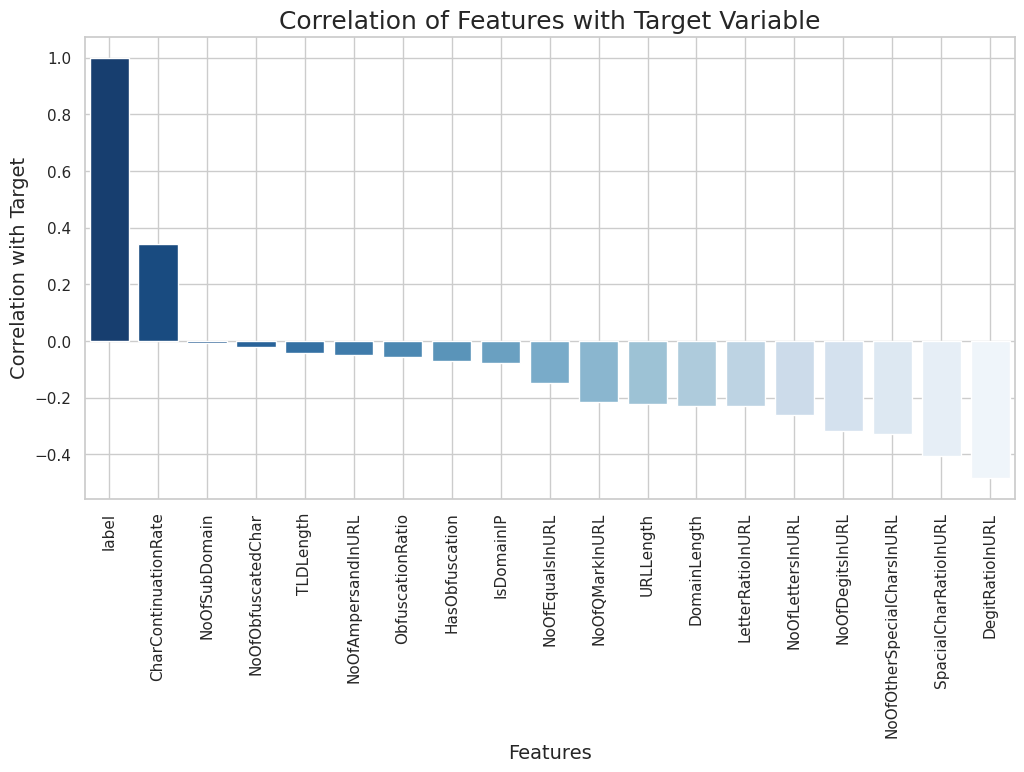

,label
label,1.000000
CharContinuationRate,0.343046
NoOfSubDomain,-0.007165
NoOfObfuscatedChar,-0.019249
TLDLength,-0.042523
NoOfAmpersandInURL,-0.050407
ObfuscationRatio,-0.056905
HasObfuscation,-0.069725
IsDomainIP,-0.077831
NoOfEqualsInURL,-0.147274


In [ ]:
url_features = [
    'URLLength', 'DomainLength', 'TLDLength', 'IsDomainIP',
    'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
    'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
    'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
    'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
    'SpacialCharRatioInURL', 'CharContinuationRate', 'label'
]


filtered_data = df[url_features]


correlation_matrix2 = filtered_data.select_dtypes(include=['number']).corr()
target_variable = 'label'
correlations_with_target = correlation_matrix2[target_variable].sort_values(ascending=False)


plt.figure(figsize=(12, 6))
sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='Blues_r')
plt.title('Correlation of Features with Target Variable', fontsize=18)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation with Target', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


correlations_with_target

Grafik diatas menunjukan seberapa besar korelasi antara fitur-fitur karaktersitik URL dengan Lable

- **Top Positif**:
  - `CharContinuationRate` (0.343046): Cenderung lebih tinggi pada URL legit (label = 1).
  
- **Top Negatif**:
  - `SpacialCharRatioInURL` (-0.406728)
  - `DegitRatioInURL` (-0.482285)
  - `NoOfOtherSpecialCharsInURL` (-0.328394)
  - Fitur ini cenderung lebih tinggi pada URL phishing (label = 0).

In [ ]:
from scipy.stats import pearsonr
# Label kolom
label_column = 'label'

# Fitur numerik terkait karakteristik URL
url_characteristics_numeric = [
    'URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain',
    'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
    'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
    'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'CharContinuationRate'
]

# Inisialisasi dictionary untuk hasil korelasi dan p-value
correlation_results = {}

# Menghitung korelasi dan p-value untuk setiap fitur numerik
for feature in url_characteristics_numeric:
    valid_data = df[[feature, label_column]].dropna()  # Menyaring baris yang tidak valid
    if len(valid_data) > 1:  # Pastikan ada lebih dari 1 baris data valid
        corr, p_value = pearsonr(valid_data[feature], valid_data[label_column])
        correlation_results[feature] = {'Correlation': corr, 'P-Value': p_value}

# Mengonversi hasil ke DataFrame
correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')
correlation_df

,Correlation,P-Value
URLLength,-0.222200,0.000000e+00
DomainLength,-0.229585,0.000000e+00
IsDomainIP,-0.077831,7.153963e-132
TLDLength,-0.042523,2.328668e-38
NoOfSubDomain,-0.007165,2.614232e-02
NoOfObfuscatedChar,-0.019249,1.763147e-07
ObfuscationRatio,-0.056905,2.070007e-55
NoOfLettersInURL,-0.259238,0.000000e+00
LetterRatioInURL,-0.229942,0.000000e+00
NoOfDegitsInURL,-0.317330,0.000000e+00


In [ ]:
from scipy.stats import chi2_contingency

# categorical features
categorical_features = ['TLD', 'IsDomainIP', 'HasObfuscation']

# Chi-Square test
chi2_results = []
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['label'])
    chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': feature, 'Chi-Square': chi2_stat, 'P-Value': p_value})

chi2_df = pd.DataFrame(chi2_results).sort_values(by='Chi-Square', ascending=False)
chi2_df


,Feature,Chi-Square,P-Value
0,TLD,26988.319288,0.000000e+00
1,IsDomainIP,581.977704,1.392808e-128
2,HasObfuscation,350.096754,4.037105e-78


# Penjelasan Hasil Analisis

# Analisis Korelasi Pearson antara Fitur URL dan Label

Hasil analisis menunjukkan korelasi Pearson dan nilai p antara setiap fitur numerik URL dan kolom `label`. Berikut adalah detail penjelasannya:

## Penjelasan Kolom
- **Correlation**: Nilai korelasi Pearson untuk setiap fitur, menunjukkan kekuatan dan arah hubungan linear:
  - Nilai mendekati 1: Hubungan positif kuat.
  - Nilai mendekati -1: Hubungan negatif kuat.
  - Nilai mendekati 0: Tidak ada hubungan linear.
- **P-Value**: Menentukan signifikansi statistik korelasi. Nilai p < 0.05 menunjukkan korelasi signifikan secara statistik.

## Temuan Utama
1. **Fitur dengan Korelasi Terkuat:**
   - **Negatif**: `DegitRatioInURL` (-0.482), menunjukkan semakin tinggi rasio digit dalam URL, semakin kecil kemungkinan nilai label tertentu.
   - **Positif**: `CharContinuationRate` (0.343), menunjukkan hubungan positif yang signifikan.

2. **Fitur Lainnya:**
   - Fitur seperti `NoOfQMarkInURL` (-0.215) dan `NoOfOtherSpecialCharsInURL` (-0.328) juga memiliki korelasi negatif signifikan.
   - Sebagian besar fitur menunjukkan hubungan signifikan (P-Value sangat kecil).




## Analisis Chi-Square untuk Fitur Kategorikal
Tabel merangkum hasil uji Chi-Square untuk fitur kategorikal (**TLD**, **IsDomainIP**, **HasObfuscation**) dan hubungannya dengan label phishing.

1. **TLD (Top-Level Domain)**:
   - **Chi-Square**: 26,988.32
   - **P-Value**: 0.0000
   - Hasil ini menunjukkan bahwa ada hubungan yang sangat signifikan antara TLD dan label phishing/non-phishing. TLD sangat mempengaruhi apakah URL tersebut phishing atau tidak.

2. **IsDomainIP**:
   - **Chi-Square**: 581.98
   - **P-Value**: 1.39e-128
   - Ini juga menunjukkan hubungan yang sangat signifikan antara apakah domain adalah IP dan label phishing/non-phishing.

3. **HasObfuscation**:
   - **Chi-Square**: 350.10
   - **P-Value**: 4.04e-78
   - Ini menunjukkan adanya hubungan yang signifikan antara apakah URL memiliki obfuscation dan label phishing/non-phishing.



## Barchart Korelasi Fitur Numerik
Barchart menggambarkan besarnya korelasi antara fitur-fitur karakteristik URL terhadap label phishing atau legit.

### Hasil Utama:
1. Fitur seperti **CharContinuationRate** menunjukkan korelasi positif yang kuat dengan label **legit**, artinya URL yang legit cenderung memiliki tingkat keberlanjutan karakter yang lebih tinggi.
2. Fitur seperti **DigitRatioInURL** dan **NoOfOtherSpecialCharsInURL** menunjukkan korelasi negatif yang kuat, yang berarti phishing URLs cenderung memiliki lebih banyak digit dan karakter khusus.
3. Beberapa fitur, seperti **TLDLength** dan **NoOfSubDomain**, memiliki korelasi yang lebih lemah, menunjukkan relevansi yang lebih rendah terhadap label phishing.


#### 3. How does website-resource-related features vary across phishing and non-phishing URLs?

Website resource related features:
- `NoOfImage`
- `NoOfCSS`
- `NoOfJS`
- `NoOfSelfRef`
- `NoOfEmptyRef`
- `NoOfExternalRef`

In [ ]:
website_resource_features = [
    'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef'
]

phishing_data = df[df[label_column] == 0]
non_phishing_data = df[df[label_column] == 1]


resource_feature_stats = pd.DataFrame({
    'Phishing_Mean': phishing_data[website_resource_features].mean(),
    'Phishing_Std': phishing_data[website_resource_features].std(),
    'Non_Phishing_Mean': non_phishing_data[website_resource_features].mean(),
    'Non_Phishing_Std': non_phishing_data[website_resource_features].std()
}).reset_index().rename(columns={'index': 'Feature'})

resource_feature_stats

,Feature,Phishing_Mean,Phishing_Std,Non_Phishing_Mean,Non_Phishing_Std
0,NoOfImage,0.887237,3.792459,44.977868,105.949319
1,NoOfCSS,0.393230,1.073604,11.064568,138.559429
2,NoOfJS,0.878481,3.522294,17.739381,21.322659
3,NoOfSelfRef,0.499928,3.448616,113.358121,225.754955
4,NoOfEmptyRef,0.154202,1.751653,4.025165,25.130241
5,NoOfExternalRef,1.167575,4.036067,84.337478,193.198483


<Figure size 1200x600 with 0 Axes>

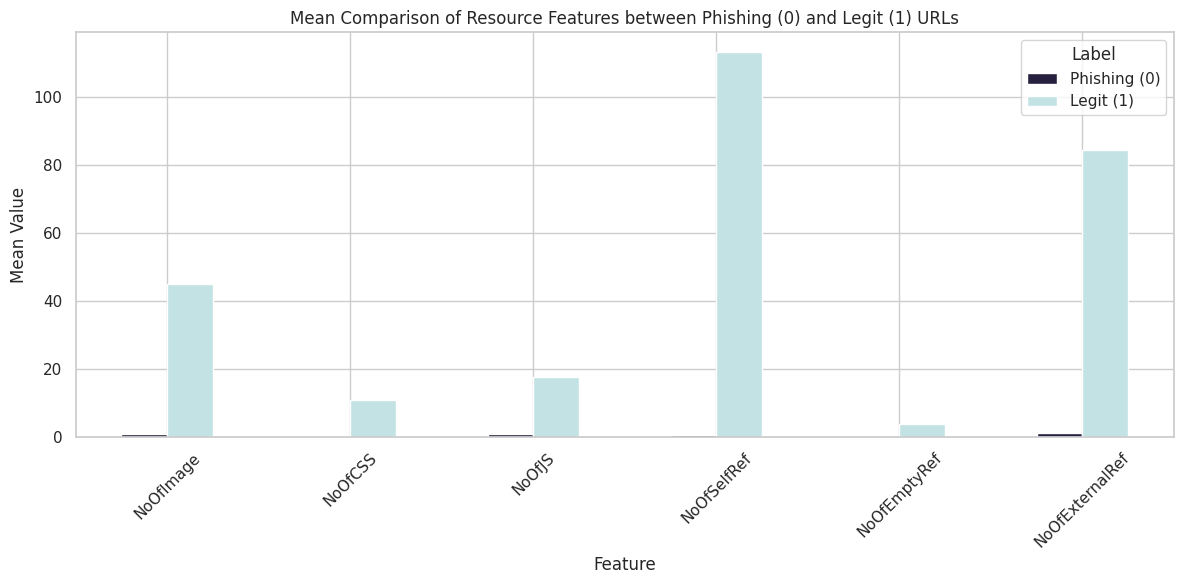

In [ ]:
plt.figure(figsize=(12, 6))
mean_stats = resource_feature_stats.set_index('Feature')[['Phishing_Mean', 'Non_Phishing_Mean']]
mean_stats.plot(kind='bar', figsize=(12, 6), color=sns.color_palette("ch:start=0.2,rot=-.3_r", n_colors=2))
plt.title("Mean Comparison of Resource Features between Phishing (0) and Legit (1) URLs")
plt.ylabel("Mean Value")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(title="Label", labels=["Phishing (0)", "Legit (1)"])
plt.tight_layout()
plt.show()


Grafik batang menunjukkan perbandingan rata-rata fitur sumber daya website antara URL phishing (0) dan URL legit (1). URL legit memiliki jumlah sumber daya yang jauh lebih tinggi dibandingkan dengan URL phishing. Sebagai contoh, URL legit rata-rata memiliki sekitar 45 gambar (NoOfImage), sedangkan URL phishing hanya sekitar 0.9. Demikian pula, URL legit rata-rata memuat sekitar 84 referensi eksternal (NoOfExternalRef), dibandingkan dengan 1.2 pada URL phishing. Sementara itu, URL phishing cenderung lebih sederhana, dengan jumlah elemen seperti CSS dan JavaScript yang sangat sedikit atau hampir nol. Hal ini menunjukkan bahwa URL phishing sering dirancang minimalis untuk memuat cepat dan menyamar sebagai situs asli, sementara URL legit lebih kompleks dengan elemen-elemen tambahan seperti gambar, CSS, dan JavaScript. Visualisasi ini memberikan wawasan yang jelas tentang pola penggunaan sumber daya dalam kedua jenis URL, yang relevan untuk proses identifikasi dan klasifikasi.

### Step 2

Try to formulate three other new questions and answer them with the methods used before.

#### 4. Are certain top-level domains (TLD) more commonly used by phishing URLs compared to non-phishing ones?


In [ ]:
phishing_tlds = df[df['label'] == 0]['TLD'].value_counts(normalize=True) * 100
non_phishing_tlds = df[df['label'] == 1]['TLD'].value_counts(normalize=True) * 100

# Gabungkan ke DataFrame untuk perbandingan
tld_comparison = pd.DataFrame({
    'Phishing (%)': phishing_tlds,
    'Non-Phishing (%)': non_phishing_tlds
}).fillna(0)

# Sort berdasarkan proporsi phishing tertinggi agar fokus ke TLD yang dominan di phishing
tld_comparison = tld_comparison.sort_values('Phishing (%)', ascending=False)

top_n = 10
print("=== TLD Distribution Table (Top 10) ===")
print(tld_comparison.head(top_n))

=== TLD Distribution Table (Top 10) ===
      Phishing (%)  Non-Phishing (%)
TLD                                 
com      42.282731         51.049285
app       6.630926          0.105782
co        5.177765          0.356018
io        3.696388          0.321895
net       3.117946          2.977809
ru        3.075621          0.650614
dev       2.468962          0.023886
org       2.200903         12.227442
top       2.200903          0.000000
link      1.424944          0.006825


# Dari tabel "TLD Distribution Table" didapatkan hasil analisis sebagai berikut:


---


1. (.com):
Phishing: ~42.3%; Non-Phishing: ~51.0%

Meskipun .com mendominasi di kedua kategori, perbedaan proporsi ini tetap signifikan karena .com adalah TLD yang paling umum secara global. Fakta bahwa .com banyak muncul pada kedua kategori menunjukkan bahwa penjahat siber maupun situs normal sama-sama memanfaatkan TLD populer ini.

2. (.app):
Phishing: ~6.6%; Non-Phishing: ~0.1%

Perbedaan ini menunjukkan bahwa phishing URL cenderung lebih memanfaatkan TLD .app dibandingkan situs non-phishing. Hal ini bisa menjadi indikasi bahwa para pelaku phishing mencoba menggunakan TLD yang mungkin kurang umum di situs legit, sehingga tampak “unik” atau memanfaatkan ekosistem TLD baru.

3. (.org):
Phishing: ~2.2%; Non-Phishing: ~12.2%



---



Sisi sebaliknya terlihat di .org, di mana TLD ini lebih banyak digunakan oleh situs non-phishing. Secara tradisional, .org sering dihubungkan dengan organisasi nirlaba atau institusi yang dapat dipercaya, sehingga natural jika proporsi .org lebih besar di non-phishing.
Selain itu, TLD lain seperti .co, .io, .net, .ru, .dev, .top, dan .link memiliki proporsi yang berbeda-beda. Beberapa TLD (.co, .io, .ru, .dev) relatif lebih sering muncul di phishing dibandingkan non-phishing (meskipun dengan persentase yang tidak terlalu besar), sementara .org yang signifikan di non-phishing menunjukkan pola distribusi yang kontras.

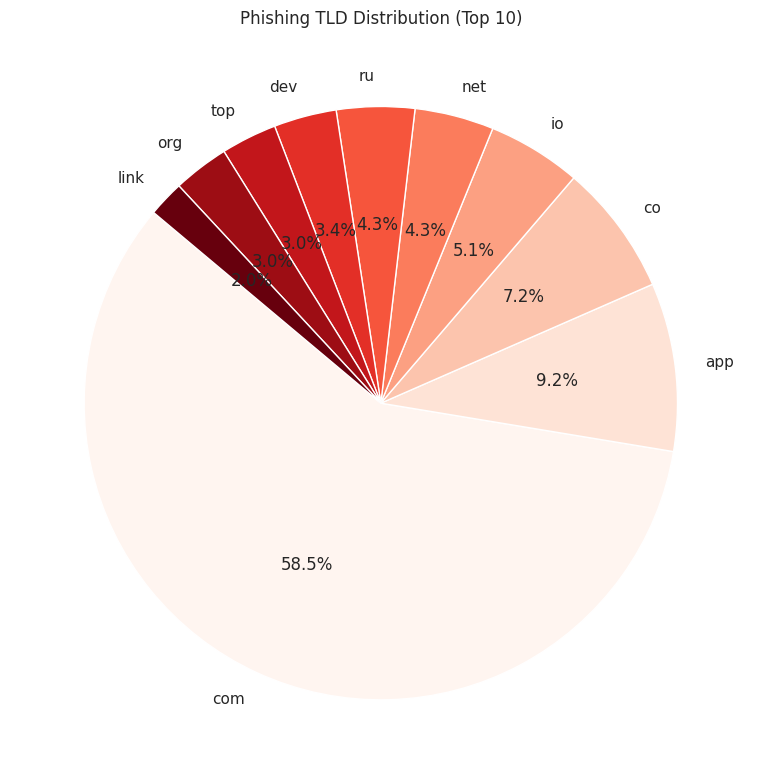

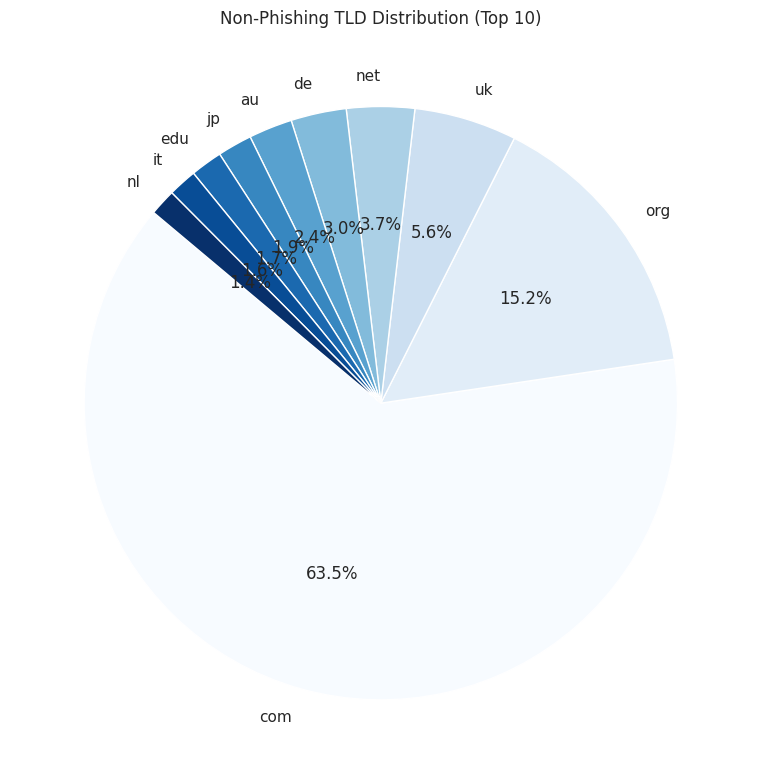

In [ ]:
top_tlds_phishing = phishing_tlds.head(top_n)
top_tlds_non_phishing = non_phishing_tlds.head(top_n)

# Pie Chart Phishing
plt.figure(figsize=(8, 8))
top_tlds_phishing.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='Reds'
)
plt.title('Phishing TLD Distribution (Top 10)')
plt.ylabel('')  # Hilangkan label default
plt.tight_layout()
plt.show()

# Pie Chart Non-Phishing
plt.figure(figsize=(8, 8))
top_tlds_non_phishing.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    cmap='Blues'
)
plt.title('Non-Phishing TLD Distribution (Top 10)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Pie Chart untuk Phishing TLD
Pie chart phishing menampilkan .com sebagai potongan terbesar. Selanjutnya diikuti oleh TLD lain yang persentasenya jauh lebih kecil. Visualisasi ini membantu memahami bahwa meskipun .com dominan, masih ada variasi TLD lain dalam porsi kecil namun signifikan secara statistik.

# Pie Chart untuk Non-Phishing TLD
Pie chart non-phishing juga menunjukkan .com sebagai dominan (~63.5% di visualisasi). Namun, .org muncul dengan proporsi yang lebih tinggi di non-phishing, mendekati 15.2%. Ini menegaskan bahwa non-phishing URL lebih beragam dalam penggunaan TLD yang kredibel dan berkaitan dengan organisasi atau entitas yang biasanya terpercaya.


<Figure size 1200x600 with 0 Axes>

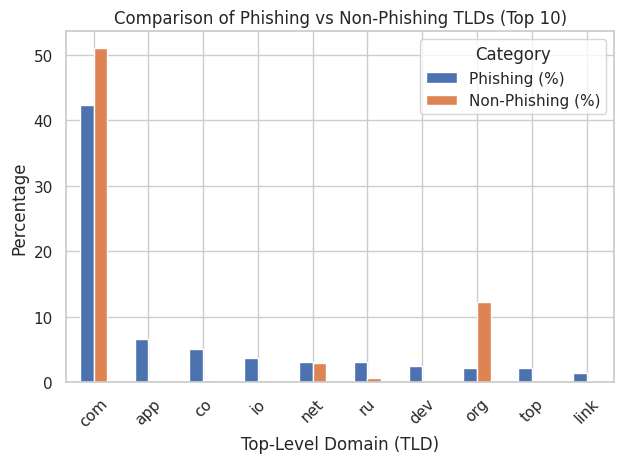

In [ ]:
# Bar Chart: Perbandingan Phishing vs Non-Phishing
tld_comparison_top = tld_comparison.head(top_n)
plt.figure(figsize=(12, 6))
tld_comparison_top.plot(kind='bar')
plt.title('Comparison of Phishing vs Non-Phishing TLDs (Top 10)')
plt.xlabel('Top-Level Domain (TLD)')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

# **Bar Chart Perbandingan Phishing vs Non-Phishing**
Bar chart memberikan perbandingan langsung:

.com tinggi di kedua kategori, tapi non-phishing sedikit lebih dominan.
.app, .co, .io, dan .ru lebih tinggi di phishing.
.org jauh lebih tinggi di non-phishing.
Bar chart mempermudah perbandingan side-by-side sehingga kita dapat melihat pola TLD yang relatif lebih condong ke salah satu kategori.

In [ ]:
contingency_table = pd.crosstab(df['TLD'], df['label'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\n=== Chi-Square Test Results ===")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"p-value: {p}")
if p < 0.05:
    print("There is a significant relationship between TLD and URL category.")
else:
    print("No significant relationship between TLD and URL category.")


=== Chi-Square Test Results ===
Chi-Square Statistic: 26988.32
p-value: 0.0
There is a significant relationship between TLD and URL category.


# Hasil Chi-Square Test:
***Chi-Square Statistic: ~26988.32***

***p-value: 0.0 (yang berarti sangat mendekati nol)***

Dengan p-value yang sangat kecil (di bawah 0.05, bahkan mendekati nol), kita memiliki bukti statistik yang sangat kuat bahwa distribusi TLD tidak terjadi secara kebetulan. Ada hubungan yang signifikan antara pemilihan TLD dan apakah sebuah URL termasuk phishing atau non-phishing.

# I
1. ***Signifikansi Praktis:***

  Keberadaan TLD tertentu yang lebih sering pada phishing URL dapat membantu sistem deteksi dini. Misalnya, jika .app ditemukan sering digunakan oleh phishing, filter atau skor risiko dapat lebih ditingkatkan untuk TLD tersebut.

2. ***Dominasi .com:***

  .com masih mendominasi di kedua kategori, ini wajar karena .com adalah TLD yang paling populer secara global. Namun, meskipun .com banyak muncul di non-phishing, jumlah yang besar pada phishing juga tidak bisa diabaikan. Ini berarti keberadaan .com saja tidak bisa menjadi indikator pasti; perlu dikombinasikan dengan fitur lain untuk mendeteksi phishing.

3. ***Diversifikasi TLD di Phishing & Non-Phishing:***

  Non-phishing tampak lebih kaya akan TLD yang secara tradisional tepercaya (misalnya .org), sementara phishing mungkin cenderung menggunakan TLD yang kurang umum di situs legit. Namun, fenomena ini bisa berubah seiring waktu, karena pelaku phishing dapat beradaptasi.

4. ***Peran Chi-Square Test:***

  Uji Chi-Square menegaskan bahwa perbedaan distribusi TLD ini bukan kebetulan. Ada pola yang konsisten dan signifikan, menandakan TLD adalah salah satu fitur yang relevan dalam pembedaan phishing vs non-phishing.

# Kesimpulan Akhir
1. Ada perbedaan signifikan dalam penggunaan TLD antara phishing dan non-phishing URL.
2. Beberapa TLD lebih condong ke phishing (misalnya .app), sementara yang lain, terutama .org, lebih dominan pada situs non-phishing.
.com digunakan secara luas di kedua kategori sehingga tidak cukup menjadi penentu tunggal.
3. Secara statistik, uji Chi-Square mengonfirmasi bahwa perbedaan ini signifikan, artinya TLD bukan faktor yang muncul secara acak dalam kaitannya dengan kategori URL.

#### 5. Do phishing URLs have different letter-to-digit ratios (LetterRatioInURL, DegitRatioInURL) compared to non-phishing URLs?



LetterRatioInURL (Phishing): Mean = 0.5651761262859171 Median = 0.571
LetterRatioInURL (Non-Phishing): Mean = 0.47661060562155905 Median = 0.48
DegitRatioInURL (Phishing): Mean = 0.06268278500382557 Median = 0.0
DegitRatioInURL (Non-Phishing): Mean = 0.0020491531962021376 Median = 0.0


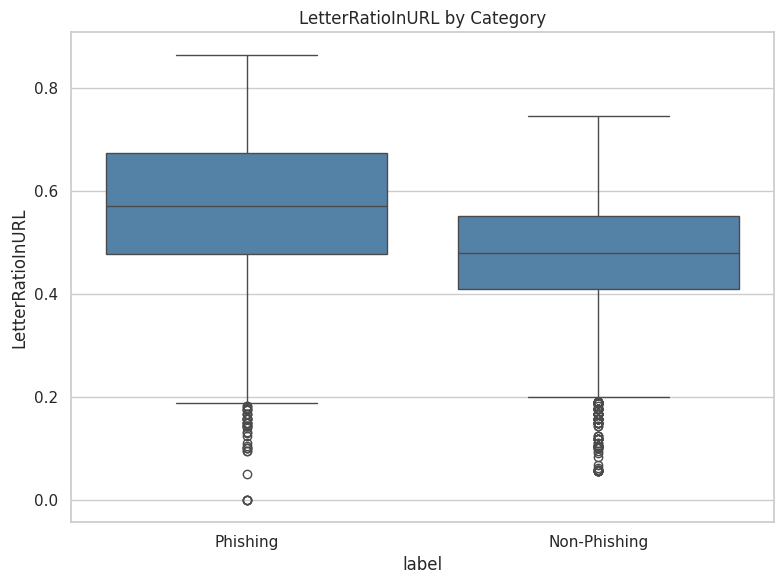

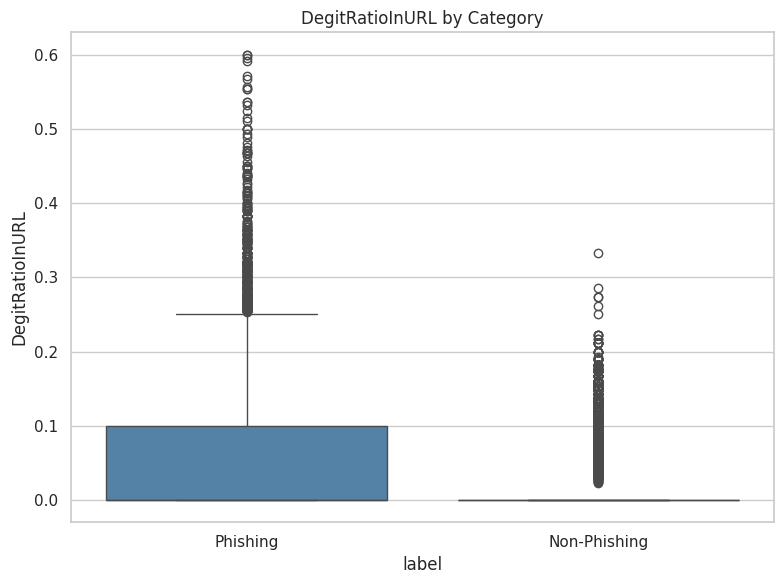

In [ ]:
# Hitung mean & median
phishing_letter_mean = df[df['label']==0]['LetterRatioInURL'].mean()
phishing_letter_median = df[df['label']==0]['LetterRatioInURL'].median()
non_phishing_letter_mean = df[df['label']==1]['LetterRatioInURL'].mean()
non_phishing_letter_median = df[df['label']==1]['LetterRatioInURL'].median()

phishing_digit_mean = df[df['label']==0]['DegitRatioInURL'].mean()
phishing_digit_median = df[df['label']==0]['DegitRatioInURL'].median()
non_phishing_digit_mean = df[df['label']==1]['DegitRatioInURL'].mean()
non_phishing_digit_median = df[df['label']==1]['DegitRatioInURL'].median()

print("LetterRatioInURL (Phishing): Mean =", phishing_letter_mean, "Median =", phishing_letter_median)
print("LetterRatioInURL (Non-Phishing): Mean =", non_phishing_letter_mean, "Median =", non_phishing_letter_median)
print("DegitRatioInURL (Phishing): Mean =", phishing_digit_mean, "Median =", phishing_digit_median)
print("DegitRatioInURL (Non-Phishing): Mean =", non_phishing_digit_mean, "Median =", non_phishing_digit_median)

# Visualisasi
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='label', y='LetterRatioInURL', color='steelblue')
plt.title('LetterRatioInURL by Category')
plt.xticks([0,1], ['Phishing','Non-Phishing'])
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='label', y='DegitRatioInURL', color='steelblue')
plt.title('DegitRatioInURL by Category')
plt.xticks([0,1], ['Phishing','Non-Phishing'])
plt.tight_layout()
plt.show()


# Statistik Deskriptif
1. LetterRatioInURL (Phishing):

  Mean ≈ 0.565

  Median ≈ 0.571

  Ini menunjukkan bahwa, secara rata-rata, sekitar 56.5% karakter dalam URL phishing adalah huruf. Median yang hampir sama dengan mean (0.571) menunjukkan distribusi yang relatif simetris (atau setidaknya tidak terlalu miring) di sekitar nilai tersebut.
2. LetterRatioInURL (Non-Phishing):

  Mean ≈ 0.477

  Median ≈ 0.48

  Non-phishing URL memiliki rata-rata sekitar 47.7% karakter berupa huruf. Median yang dekat dengan mean (0.48) juga menunjukkan keselarasan dalam distribusi. Nilai ini lebih rendah dari phishing, yang dapat mengindikasikan bahwa URL legit (non-phishing) cenderung memiliki proporsi huruf yang sedikit lebih rendah.
3. DegitRatioInURL (Phishing):

  Mean ≈ 0.0627 (atau 6.27%)

  Median = 0.0

  Rata-rata rasio digit di phishing URL sekitar 6.27%, namun median 0.0 menunjukkan bahwa sebagian besar URL sebenarnya memiliki rasio digit sangat rendah (bahkan nol). Adanya mean yang lebih tinggi dari median mengindikasikan bahwa sejumlah kecil URL phishing memiliki banyak digit sehingga "menarik" rata-ratanya ke atas. Dengan kata lain, mayoritas URL phishing mungkin tidak mengandung banyak angka, tetapi ada beberapa yang sangat kaya digit, sehingga menaikkan rata-rata.
4. DegitRatioInURL (Non-Phishing):

  Mean ≈ 0.0020 (0.2%)

  Median = 0.0

  Rata-rata rasio digit pada non-phishing URL sangat kecil (hanya 0.2%), dan median nol menandakan mayoritas besar non-phishing URL sama sekali tidak mengandung digit atau mengandung sangat sedikit. Tidak banyak URL non-phishing yang memuat angka secara signifikan.

# Interpretasi dari Statistik:
1. LetterRatioInURL:

  Phishing URL memiliki proporsi huruf lebih tinggi (mean dan median sekitar 0.57) dibandingkan non-phishing (mean dan median sekitar 0.48). Ini mengindikasikan bahwa phishing URL mungkin mencoba terlihat seperti kata-kata biasa, nama domain yang meyakinkan, atau meniru nama brand, sehingga menggunakan lebih banyak huruf. Non-phishing URL, meskipun juga mayoritas huruf, cenderung sedikit lebih rendah rasionya, mungkin karena URL-URL legit sering memuat karakter lain seperti tanda hubung, garis miring, atau struktur domain yang berbeda-beda (subdomain, parameter, dll.).

2. DegitRatioInURL:

  Pada phishing URL, meskipun median 0 menunjukkan sebagian besar URL tidak mengandung banyak digit, nilai mean yang mencapai 0.0627 mengindikasikan ada sekelompok kecil phishing URL yang memiliki rasio digit sangat tinggi. Ini mungkin taktik untuk membuat URL sulit dibaca atau menyerupai karakter tertentu (misal mengganti huruf ‘O’ dengan angka ‘0’) untuk mengecoh pengguna.
  Pada non-phishing, mean dan median yang sangat rendah (praktis mendekati nol) menunjukkan bahwa angka sangat jarang digunakan. URL legit mungkin tetap sederhana atau jika menggunakan angka, jumlahnya sangat terbatas.

# Visualisasi Boxplot:
1. LetterRatioInURL by Category:
  
  Boxplot phishing: median sekitar 0.57, kotak terpusat pada nilai yang relatif tinggi. Rentang interkuartil (IQR) yang tampak mungkin cukup rapat, menunjukkan bahwa sebagian besar nilai berkumpul di sekitar kisaran tersebut (sekitar 0.48 sampai 0.67).
  
  Boxplot non-phishing:
  median sekitar 0.48, sedikit lebih rendah. Distribusi non-phishing terlihat memiliki IQR yang mungkin lebih lebar atau lebih rendah, artinya proporsi hurufnya sedikit lebih bervariasi atau cenderung ke angka yang lebih rendah daripada phishing.

  Secara visual, jelas terlihat boxplot phishing berada pada level yang lebih tinggi daripada non-phishing. Hal ini konsisten dengan statistik mean dan median yang didapat.


2. DegitRatioInURL by Category:
  
  Boxplot phishing: median 0.0, tetapi ada whisker dan banyak outlier yang naik cukup tinggi, bahkan hingga 0.6. Ini menunjukkan bahwa sebagian besar nilai dekat dengan nol, namun ada URL yang sangat tinggi digitnya, menciptakan rentang outlier ke atas yang signifikan.

  Boxplot non-phishing: median juga 0.0, dengan hampir seluruh data mendekati nol dan sangat sedikit outlier yang muncul ke atas. Hal ini menandakan non-phishing URL hampir selalu memiliki rasio digit yang sangat kecil atau nol.

  Secara visual, boxplot phishing "terangkat" oleh kehadiran sejumlah data ekstrem (outlier) yang sangat kaya akan digit. Sedangkan non-phishing URL nyaris tidak memiliki angka, sehingga boxplotnya sangat rapat di dekat nol.

# Kesimpulan:
1. Perbedaan Letter Ratio: Phishing URLs cenderung memiliki proporsi huruf yang lebih tinggi, menunjukkan upaya untuk terlihat “natural” atau menyerupai nama domain sah.
2. Perbedaan Digit Ratio: Walaupun mayoritas phishing dan non-phishing sama-sama rendah digitnya (median 0.0), phishing memiliki segelintir URL dengan banyak digit. Ini dapat menjadi pola: beberapa phishing URL mencoba membingungkan pengguna dengan kombinasi karakter alfanumerik yang kompleks.
3. Tanpa Uji Statistik: Hasil ini adalah interpretasi deskriptif dan visual. Kita belum menentukan signifikansi statistik, tapi dari gambaran ini terlihat pola distribusi yang berbeda.
4. Makna untuk Deteksi Phishing: Jika seseorang ingin mendeteksi phishing, fokus dapat diberikan pada URL dengan rasio digit tinggi karena hal ini tampaknya lebih umum (walau tidak mayoritas) di phishing. Selain itu, analisis letter ratio dapat memberi sinyal bahwa phishing URL cenderung punya domain yang penuh huruf (mungkin nama brand palsu), sementara non-phishing mungkin lebih berimbang.


#### 6. Is the number of lines of code (LineOfCode) significantly higher or lower for phishing URLs compared to non-phishing ones?

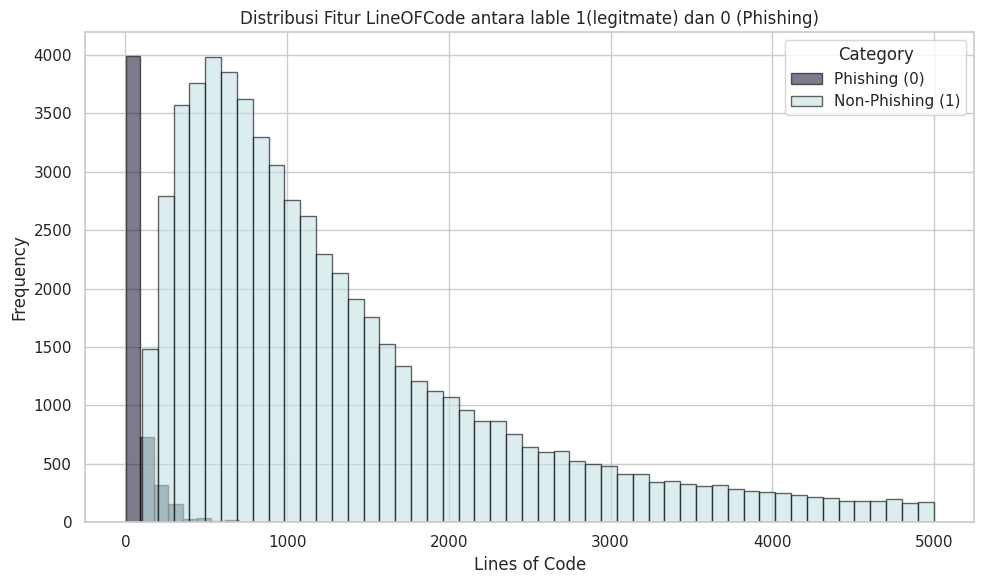

In [ ]:
phishing_lines = df[df['label'] == 0]['LineOfCode'].dropna()
non_phishing_lines = df[df['label'] == 1]['LineOfCode'].dropna()

# ganti ke numeric dan ilangin outliers biar visualisasinya ga ancur
phishing_lines_final = phishing_lines[
    (pd.to_numeric(phishing_lines, errors='coerce').notnull()) & (phishing_lines <= 5000)
]
non_phishing_lines_final = non_phishing_lines[
    (pd.to_numeric(non_phishing_lines, errors='coerce').notnull()) & (non_phishing_lines <= 5000)
]
sns.set(style="whitegrid", palette="ch:start=0.2,rot=-.3_r")


plt.figure(figsize=(10, 6))
plt.hist(
    phishing_lines_final, bins=50, alpha=0.6,
    label="Phishing (0)",
    color=sns.color_palette("ch:start=0.2,rot=-.3_r", n_colors=2)[0],
    edgecolor='black'
)

plt.hist(
    non_phishing_lines_final, bins=50, alpha=0.6,
    label="Non-Phishing (1)",
    color=sns.color_palette("ch:start=0.2,rot=-.3_r", n_colors=2)[1],
    edgecolor='black'
)
plt.title("Distribusi Fitur LineOFCode antara lable 1(legitmate) dan 0 (Phishing)")
plt.xlabel("Lines of Code")
plt.ylabel("Frequency")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

In [ ]:
phishing_stats = phishing_lines.describe()
non_phishing_stats = non_phishing_lines.describe()

stats_table = pd.DataFrame({
    "Phishing (0)": phishing_stats,
    "Non-Phishing (1)": non_phishing_stats
}).rename(index={
    "count": "Count",
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "25%": "25th Percentile",
    "50%": "Median (50th Percentile)",
    "75%": "75th Percentile",
    "max": "Maximum"
})

stats_table

,Phishing (0),Non-Phishing (1)
Count,5317.000000,65934.000000
Mean,63.061501,1936.803698
Standard Deviation,150.526296,3887.631974
Minimum,2.000000,102.000000
25th Percentile,2.000000,614.000000
Median (50th Percentile),12.000000,1110.000000
75th Percentile,88.000000,2088.000000
Maximum,4397.000000,440155.000000


Dari analisis yang dilakukan, kita mendapat insight bahwa rata-rata baris kode dalam URL phishing itu jauh lebih rendah dari pada URL yang legit. URL phsing memiliki rata-rata jumlah barus sekiar 63 yang menggambarkan bahwa URL tersebut didesain lebih sederhana dibanding URL yang legit yang memiliki rata-rata 1936 baris, yang menandakan situs tersebut jauh lebih kompleks.

Kita bisa lihat visualisasi distribusinya pada grafik histogram diatas, terlihat jelas bahwa URL phishing memiliki distribusi banyak baris kode yang jauh sedikit
